# Personal Relation Task analysis

## Import libraries

In [80]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from pathlib import Path
from scipy import stats
import numpy as np

# Set display options for DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

base_path = Path(r"c:\Users\Bart Evelo\OneDrive\Documenten\Universiteit\Linguistics\Thesis\Thesis Coding")
output_path = base_path / "analysis" / "outputs" / "analysis"

# Create output directory if it doesn't exist
os.makedirs(output_path, exist_ok=True)

## Load all data

##### Some helpfull function to load the data

jsonl files: these are returned from openai batch request. Each combination of representation and approach variable is in its own file.
csv files: these are generated by local (snelius) run LLMs. One csv file for all combinations of representation and approach variable.

load_responses_from_jsonl: loads the responses from the jsonl file. These files are returned from OpenAI batch request
load_responses_from_csv: loads responses from csv files. These are generated by local (snellius) run LLMs
merge_with_metedata: Merges the csv file with the different dataset files.

In [81]:
def load_responses(jsonl_path):
    responses = []
    with open(jsonl_path, 'r') as file:
        for line in file:
            try:
                response = json.loads(line)
                # Check if the response was successful and contains token information
                if (response.get('error') is None and 
                    response.get('response', {}).get('status_code') == 200):
                    
                    body = response.get('response', {}).get('body', {})
                    usage = body.get('usage', {})
                    custom_id = response.get('custom_id', '')
                    
                    # Extract token metrics
                    prompt_tokens = usage.get('prompt_tokens', 0)
                    completion_tokens = usage.get('completion_tokens', 0)
                    
                    # Extract reasoning tokens from the completion_tokens_details
                    completion_tokens_details = usage.get('completion_tokens_details', {})
                    reasoning_tokens = completion_tokens_details.get('reasoning_tokens', 0)
                    
                    # Calculate pure output tokens (excluding reasoning)
                    output_tokens = completion_tokens - reasoning_tokens
                    
                    # Extract additional information
                    choices = body.get('choices', [{}])
                    message = choices[0].get('message', {}) if choices else {}
                    
                    responses.append({
                        'QuestionId': custom_id,  # To match with metadata
                        'Prompt_tokens': prompt_tokens,
                        'Completion_tokens': completion_tokens,
                        'Reasoning_tokens': reasoning_tokens,
                        'Output_tokens': output_tokens,
                        'Model': body.get('model', ''),
                        'Model_Answer': message.get('content', ''),
                        'Refusal': message.get('refusal') is not None,  # Convert to boolean
                        'Finish_reason': choices[0].get('finish_reason', '') if choices else '',
                        'Created': body.get('created', 0),
                        'Request_id': response.get('response', {}).get('request_id', '')
                    })
            except json.JSONDecodeError:
                print(f"Failed to parse line: {line}")
    
    return pd.DataFrame(responses)


def load_responses_from_csv(csv_path):
    """
    Load model response data from a CSV file and format it similarly to JSONL responses.
    Works with different CSV formats without creating duplicate columns.
    
    Args:
        csv_path: Path to the CSV file
    
    Returns:
        pandas DataFrame with standardized columns
    """
    # Read the CSV file as-is
    df = pd.read_csv(csv_path)
    # print all columns
    columns_to_drop = ['Complexity', 'Branching','Prompt', 'Question','Duration','Timestamp']
    df = df.drop(columns=columns_to_drop, errors='ignore')
    
    # if token columns are not present, create them with 0 values
    token_columns = ["Input_Tokens", "Output_Tokens", "Total_Tokens", "Reasoning_Tokens"]
    for col in token_columns:
        if col not in df.columns:
            df[col] = np.nan  # Use NaN instead of 0 for missing values
            
    # Rename columns to match the expected format
    df = df.rename(columns={
        'Input_Tokens': 'Prompt_tokens',
        'Output_Tokens': 'Output_tokens',
        'Total_Tokens': 'Completion_tokens',
        'Reasoning_Tokens': 'Reasoning_tokens'
    })

    return df
    

def merge_with_metadata(df, metadata_files):
    merged_df = pd.DataFrame()
    for (lang, app), group_df in df.groupby(['Representation', 'Approach']):
        # clean off any enum‐prefixes and lowercase
        lang_key = str(lang).split('.')[-1].lower()
        app_key  = str(app).split('.')[-1].lower()
        metadata_key = f"{lang_key}_{app_key}"
        metadata = metadata_files.get(metadata_key)
        if metadata is not None:
            metadata_copy = metadata.copy()
            cols_to_drop = [c for c in metadata_copy.columns if c in group_df.columns and c!='QuestionId']
            metadata_copy.drop(columns=cols_to_drop, errors='ignore', inplace=True)
            group_merged = pd.merge(group_df, metadata_copy, on='QuestionId', how='left')
            sample_row = metadata.iloc[0] if not metadata.empty else None
            if sample_row is not None:
                group_merged["Representation"] = sample_row.get("Representation", lang)
                group_merged["Approach"]  = sample_row.get("Approach",  app)
            merged_df = pd.concat([merged_df, group_merged], ignore_index=True)
        else:
            print(f"Warning: No metadata for key {metadata_key}")
            merged_df = pd.concat([merged_df, group_df], ignore_index=True)
    return merged_df


# Function to preprocess metadata files
def preprocess_metadata(metadata_df):
    """
    Process metadata DataFrame to:
    1. Combine prompt_1 + question_universe + prompt_2 into a single 'prompt' column
    2. Remove the options column
    3. Keep other columns unchanged
    
    Returns the processed DataFrame
    """
    # Create a copy to avoid modifying the original
    df = metadata_df.copy()
    
    # Create a new prompt column by combining prompt_1 + question_universe + prompt_2
    # Handle potential NaN values by using fillna with empty string
    df['prompt'] = (df['prompt_1'].fillna('') + ' ' + 
                   df['question_universe'].fillna('') + ' ' + 
                   df['prompt_2'].fillna(''))
    
    # Clean up any extra spaces
    df['prompt'] = df['prompt'].str.strip()
    
    # Drop the columns we no longer need
    columns_to_drop = ['prompt_1', 'prompt_2', 'options', 'question_universe']
    df = df.drop(columns=columns_to_drop, errors='ignore')
    
    return df

In [82]:
# Load the prompts, correct answers and variables
abstract_extensional_file = base_path / "analysis" / "results" / "pilot" / "models" / "abstract_extensional.csv"
abstract_intensional_file = base_path / "analysis" / "results" / "pilot" / "models" / "abstract_intensional.csv"
english_extensional_file = base_path / "analysis" / "results" / "pilot" / "models" / "english_extensional.csv"
english_intensional_file = base_path / "analysis" / "results" / "pilot" / "models" / "english_intensional.csv"

# Process each metadata file
abstract_extensional = preprocess_metadata(pd.read_csv(abstract_extensional_file))
abstract_intensional = preprocess_metadata(pd.read_csv(abstract_intensional_file))
english_extensional = preprocess_metadata(pd.read_csv(english_extensional_file))
english_intensional = preprocess_metadata(pd.read_csv(english_intensional_file))

# Rename 'questionId' to 'QuestionId' in all metadata DataFrames for consistency
abstract_extensional.rename(columns={'questionId': 'QuestionId'}, inplace=True)
abstract_intensional.rename(columns={'questionId': 'QuestionId'}, inplace=True)
english_extensional.rename(columns={'questionId': 'QuestionId'}, inplace=True)
english_intensional.rename(columns={'questionId': 'QuestionId'}, inplace=True)

metadata_files = {
    'abstract_extensional': abstract_extensional,
    'abstract_intensional': abstract_intensional,
    'english_extensional': english_extensional,
    'english_intensional': english_intensional
}

# Load the results
o3mini_high_file = base_path / "analysis" / "results" / "pilot" / "o3mini-high.jsonl"
o3mini_low_file = base_path / "analysis" / "results" / "pilot" /"o3mini-low.jsonl"
llama33_file_first = base_path / "analysis" / "results" / "pilot" / "meta-llama-Llama-3.3-70B-Instruct_results_first.csv"
llama33_file = base_path / "analysis" / "results" / "pilot" / "meta-llama-Llama-3.3-70B-Instruct_results.csv"

o3mini_high_results = load_responses(o3mini_high_file)
o3mini_low_results = load_responses(o3mini_low_file)
llama33_first_results = load_responses_from_csv(llama33_file_first)
llama33_results = load_responses_from_csv(llama33_file)

#combine llama33 results
llama33_results = pd.concat([llama33_first_results, llama33_results], ignore_index=True)

# Combine the results with the metadata
# o3mini should be combined with the abstract extensional
o3mini_high_merged = pd.merge(o3mini_high_results, abstract_extensional, on='QuestionId', how='left')
o3mini_low_merged = pd.merge(o3mini_low_results, abstract_extensional, on='QuestionId', how='left')
llama33_merged = merge_with_metadata(llama33_results, metadata_files)

# Add model variant for identification
o3mini_high_merged['Model_variant'] = 'o3mini-high'
o3mini_low_merged['Model_variant'] = 'o3mini-low' 
llama33_merged['Model_variant'] = 'llama-3.3-70B'

llms_results = pd.concat([o3mini_high_merged, o3mini_low_merged, llama33_merged], ignore_index=True)

display(llama33_merged.sample(5))


,Representation,Approach,QuestionId,Correct_Answer,Model_Answer,Model,Prompt_tokens,Output_tokens,Completion_tokens,Reasoning_tokens,Complexity,Branching,Question,Answer,prompt,Model_variant
280,Representation.ENGLISH,SemanticApproach.EXTENSIONAL,0_L_ffeff0,Bryan,"Imagine there are six people: Amber, Bryan, Ch...",meta-llama/Llama-3.3-70B-Instruct,233.0,477.0,710.0,NaN,6,L,Christina's friend's friend's enemy's friend's...,Bryan,"Imagine there are six people: Amber, Bryan, Ch...",llama-3.3-70B
461,Representation.ENGLISH,SemanticApproach.EXTENSIONAL,1_R_cfece2,Breanna,"Imagine there are six people: Annette, Breanna...",meta-llama/Llama-3.3-70B-Instruct,269.0,731.0,1000.0,NaN,6,R,the child of the friend of the enemy of the ch...,Breanna,"Imagine there are six people: Annette, Breanna...",llama-3.3-70B
291,Representation.ENGLISH,SemanticApproach.EXTENSIONAL,0_L_eeeee1,Elizabeth,"Imagine there are six people: Amber, Bryan, Ch...",meta-llama/Llama-3.3-70B-Instruct,233.0,477.0,710.0,NaN,6,L,Amber's enemy's enemy's enemy's enemy's enemy,Elizabeth,"Imagine there are six people: Amber, Bryan, Ch...",llama-3.3-70B
71,Representation.ENGLISH,SemanticApproach.EXTENSIONAL,0_R_ecf5,Elizabeth,"Imagine there are six people: Amber, Bryan, Ch...",meta-llama/Llama-3.3-70B-Instruct,NaN,NaN,NaN,NaN,4,R,the enemy of the child of the friend of Felicia,Elizabeth,"Imagine there are six people: Amber, Bryan, Ch...",llama-3.3-70B
115,Representation.ENGLISH,SemanticApproach.EXTENSIONAL,0_R_eecf5,Amber,"Imagine there are six people: Amber, Bryan, Ch...",meta-llama/Llama-3.3-70B-Instruct,NaN,NaN,NaN,NaN,5,R,the enemy of the enemy of the child of the fri...,Amber,"Imagine there are six people: Amber, Bryan, Ch...",llama-3.3-70B


## Perform some basic analys

In [83]:
# Filter out extra questions from o3mini-high to match o3mini-low
common_questions = o3mini_low_merged['QuestionId'].unique()
o3mini_high_filtered = o3mini_high_merged[o3mini_high_merged['QuestionId'].isin(common_questions)]

# Function to extract the answer from the 'Model_Answer' column
def extract_answer(model_answer):
    if pd.isna(model_answer):
        return None
    if "So the answer is" in model_answer:
        try:
            return model_answer.split("So the answer is")[-1].split()[0].split(".")[0].strip()
        except IndexError:
            return None
    return None

llms_results = pd.concat([
    o3mini_high_filtered,
    o3mini_low_merged,
    llama33_merged
], ignore_index=True)

# Apply the function to extract answers for each model
llms_results['Extracted_Answer'] = llms_results['Model_Answer'].apply(extract_answer)
o3mini_high_filtered['Extracted_Answer'] = o3mini_high_filtered['Model_Answer'].apply(extract_answer)
o3mini_low_merged['Extracted_Answer'] = o3mini_low_merged['Model_Answer'].apply(extract_answer)
llama33_merged['Extracted_Answer'] = llama33_merged['Model_Answer'].apply(extract_answer)

# Determine correctness by comparing extracted answers with the 'Answer' column
llms_results['Correct'] = llms_results['Extracted_Answer'] == llms_results['Answer']
# Determine correctness for each model
o3mini_high_filtered['Correct'] = o3mini_high_filtered['Extracted_Answer'] == o3mini_high_filtered['Answer']
o3mini_low_merged['Correct'] = o3mini_low_merged['Extracted_Answer'] == o3mini_low_merged['Answer']
llama33_merged['Correct'] = llama33_merged['Extracted_Answer'] == llama33_merged['Answer']


# Display the first few rows of the processed datasets to verify correctness
display(llama33_merged.sample(5))

C:\Users\Bart Evelo\AppData\Local\Temp\ipykernel_10144\3929667977.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  o3mini_high_filtered['Extracted_Answer'] = o3mini_high_filtered['Model_Answer'].apply(extract_answer)
C:\Users\Bart Evelo\AppData\Local\Temp\ipykernel_10144\3929667977.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  o3mini_high_filtered['Correct'] = o3mini_high_filtered['Extracted_Answer'] == o3mini_high_filtered['Answer']


,Representation,Approach,QuestionId,Correct_Answer,Model_Answer,Model,Prompt_tokens,Output_tokens,Completion_tokens,Reasoning_tokens,Complexity,Branching,Question,Answer,prompt,Model_variant,Extracted_Answer,Correct
125,Representation.ENGLISH,SemanticApproach.EXTENSIONAL,0_R_pfece0,Felicia,"Imagine there are six people: Amber, Bryan, Ch...",meta-llama/Llama-3.3-70B-Instruct,NaN,NaN,NaN,NaN,6,R,the parent of the friend of the enemy of the c...,Felicia,"Imagine there are six people: Amber, Bryan, Ch...",llama-3.3-70B,[answer]',False
69,Representation.ENGLISH,SemanticApproach.EXTENSIONAL,0_R_fff5,Bryan,"Imagine there are six people: Amber, Bryan, Ch...",meta-llama/Llama-3.3-70B-Instruct,NaN,NaN,NaN,NaN,4,R,the friend of the friend of the friend of Felicia,Bryan,"Imagine there are six people: Amber, Bryan, Ch...",llama-3.3-70B,Bryan,True
246,Representation.ENGLISH,SemanticApproach.EXTENSIONAL,0_L_cfec0,Elizabeth,"Imagine there are six people: Amber, Bryan, Ch...",meta-llama/Llama-3.3-70B-Instruct,231.0,433.0,664.0,NaN,5,L,Christina's child's enemy's friend's child,Elizabeth,"Imagine there are six people: Amber, Bryan, Ch...",llama-3.3-70B,Elizabeth,True
343,Representation.ENGLISH,SemanticApproach.EXTENSIONAL,1_R_ff3,Frank,"Imagine there are six people: Annette, Breanna...",meta-llama/Llama-3.3-70B-Instruct,263.0,737.0,1000.0,NaN,3,R,the friend of the friend of Frank,Frank,"Imagine there are six people: Annette, Breanna...",llama-3.3-70B,Annette,False
97,Representation.ENGLISH,SemanticApproach.EXTENSIONAL,0_R_ffef2,Amber,"Imagine there are six people: Amber, Bryan, Ch...",meta-llama/Llama-3.3-70B-Instruct,NaN,NaN,NaN,NaN,5,R,the friend of the friend of the enemy of the f...,Amber,"Imagine there are six people: Amber, Bryan, Ch...",llama-3.3-70B,Amber,True


In [84]:

# List of stratification columns
strata = ['Approach', 'Representation', 'Branching', 'Complexity']

# Container for the balanced data
balanced_df = pd.DataFrame()

for df in [o3mini_high_filtered, o3mini_low_merged]:
    for group_keys, group_data in df.groupby(strata):
        # Check if both variants are present in the current group
        variants = group_data['Model_variant'].unique()
        if len(variants) < 2:
            # If only one variant is present, you might decide to skip this stratum
            # or handle it differently depending on your analysis needs.
            continue

        # Determine the smallest count among variants in this stratum
        min_count = group_data.groupby('Model_variant').size().min()

        # Sample min_count rows for each variant within the stratum
        sampled = group_data.groupby('Model_variant', group_keys=False)\
                            .apply(lambda x: x.sample(min_count, random_state=42))
        
        # Append the sampled data to the balanced DataFrame
        balanced_df = pd.concat([balanced_df, sampled], ignore_index=True)
        df = balanced_df.copy()
        
o3mini_high_without_friends = o3mini_high_filtered.copy()
o3mini_low_without_friends = o3mini_low_merged.copy()
o3mini_high_with_friends = o3mini_high_filtered.copy()
o3mini_low_with_friends = o3mini_low_merged.copy()
o3mini_high_without_friends["Model_variant"] = "o3mini-high-no-friends"
o3mini_low_without_friends["Model_variant"] = "o3mini-low-no-friends"
o3mini_high_with_friends["Model_variant"] = "o3mini-high-only-friends"
o3mini_low_with_friends["Model_variant"] = "o3mini-low-only-friends"

# Filter out the friends questions from the o3mini-high and o3mini-low datasets
o3mini_high_without_friends = o3mini_high_without_friends[~o3mini_high_without_friends['QuestionId'].str.contains('f', na=False)]
o3mini_low_without_friends = o3mini_low_without_friends[~o3mini_low_without_friends['QuestionId'].str.contains('f', na=False)]
o3mini_high_with_friends = o3mini_high_with_friends[o3mini_high_with_friends['QuestionId'].str.contains('f', na=False)]
o3mini_low_with_friends = o3mini_low_with_friends[o3mini_low_with_friends['QuestionId'].str.contains('f', na=False)]


llms_results = pd.concat([
    o3mini_high_filtered,
    o3mini_low_merged,
    o3mini_high_without_friends,
    o3mini_low_without_friends,
    o3mini_high_with_friends,
    o3mini_low_with_friends
], ignore_index=True)

In [ ]:
def calculate_accuracy_with_ci(data):
    total = len(data)
    correct = data['Correct'].sum()
    accuracy = correct / total if total > 0 else 0

    # Calculate 95% confidence interval using the Wilson score interval
    if total > 0:
        z = 1.96  # 95% confidence
        p = accuracy
        denom = 1 + (z**2 / total)
        center = (p + z**2 / (2 * total)) / denom
        err = z * np.sqrt(p * (1 - p) / total + z**2 / (4 * total**2)) / denom
        ci_lower = max(0, center - err)
        ci_upper = min(1, center + err)
    else:
        ci_lower, ci_upper = 0, 0

    return {
        'Total': total,
        'Correct': correct,
        'Accuracy': accuracy,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper
    }


def analyze_data_by_dimension(data, dimension, model_col='Model_variant', heatmap_col=None):
    """
    Analyze accuracy by any dimension (e.g., Representation, Approach, Complexity, Branching)
    
    Args:
        data: DataFrame with the data
        dimension: Column name to analyze by (e.g., 'Representation', 'Approach', 'Complexity')
        model_col: Column containing model names
        heatmap_col: Optional second dimension for heatmap (e.g., when dimension='Complexity', 
                    heatmap_col could be 'Branching')
    
    Returns:
        Dictionary with analysis results
    """
    # Create dictionary to store results
    results = {}
    
    # Calculate accuracy by the specified dimension
    for model in data[model_col].unique():
        model_data = data[data[model_col] == model]
        results[model] = {}
        
        for value in model_data[dimension].unique():
            subset = model_data[model_data[dimension] == value]
            results[model][value] = calculate_accuracy_with_ci(subset)
    
    # Create DataFrame for visualization
    df = pd.DataFrame({
        'Model': [],
        dimension: [],
        'Total': [],
        'Correct': [],
        'Accuracy': [],
        'CI_Lower': [],
        'CI_Upper': []
    })
    
    for model in results:
        for value in results[model]:
            stats = results[model][value]
            temp_df = pd.DataFrame({
                'Model': [model],
                dimension: [value],
                'Total': [stats['Total']],
                'Correct': [stats['Correct']],
                'Accuracy': [stats['Accuracy']],
                'CI_Lower': [stats['CI_Lower']],
                'CI_Upper': [stats['CI_Upper']]
            })
            df = pd.concat([df, temp_df], ignore_index=True)
    
    # If heatmap column is provided, create a pivot table
    heatmap_data = None
    if heatmap_col:
        heatmap_data = {}
        for model in data[model_col].unique():
            model_data = data[data[model_col] == model]
            # Create pivot table for the model
            pivot = pd.pivot_table(
                model_data,
                values='Correct', 
                index=dimension,
                columns=heatmap_col,
                aggfunc=lambda x: sum(x) / len(x)
            )
            heatmap_data[model] = pivot
    
    return {
        'results': results,
        'df': df,
        'heatmap_data': heatmap_data
    }

def create_result_table(df, dimension):
    """Display a formatted table of results"""
    table = df.sort_values(['Model', dimension]).reset_index(drop=True)
    print(f"Accuracy by {dimension}:")
    display(table)
    return table

def plot_bar_chart(df, dimension, title=None):
    """Create a bar chart for the specified dimension"""
    plt.figure(figsize=(12, 6))
    
    # Get unique models and dimension values
    models = df['Model'].unique()
    values = sorted(df[dimension].unique())
    x = np.arange(len(values))
    width = 0.8 / len(models)
    
    # Plot bars for each model
    for i, model in enumerate(models):
        model_data = df[df['Model'] == model].sort_values(dimension)
        positions = x - 0.4 + width/2 + i * width
        bars = plt.bar(positions, model_data['Accuracy'], width=width, label=model)
        
        # Add error bars
        plt.errorbar(
            positions,
            model_data['Accuracy'],
            yerr=[model_data['Accuracy'] - model_data['CI_Lower'], 
                 model_data['CI_Upper'] - model_data['Accuracy']],
            fmt='none', ecolor='black', capsize=5
        )
    
    # Add labels and formatting
    if not title:
        title = f'Accuracy by {dimension}'
    plt.title(title, fontsize=15)
    plt.xlabel(dimension, fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.xticks(x, values)
    plt.ylim(0, 1.0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    
    # Save the plot
    plt.savefig( / f'accuracy_by_{dimension.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_line_chart(df, dimension, title=None):
    plt.figure(figsize=(12, 6))
    models = df['Model'].unique()

    for model in models:
        model_data = df[df['Model'] == model].sort_values(dimension)
        vals = model_data[dimension].tolist()
        acc = model_data['Accuracy'].tolist()
        lower = np.maximum(0, acc - model_data['CI_Lower']).tolist()
        upper = np.maximum(0, model_data['CI_Upper'] - acc).tolist()

        plt.errorbar(
            vals,
            acc,
            yerr=[lower, upper],
            marker='o',
            linestyle='-',
            label=model,
            color=COLOR_MAP.get(model, None)               # ← use the same map
        )
    
    # Add labels and formatting
    if not title:
        title = f'Accuracy by {dimension}'
    plt.title(title, fontsize=15)
    plt.xlabel(dimension, fontsize=12) 
    plt.ylabel('Accuracy', fontsize=12)
    plt.ylim(0, 1.0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    
    # Save the plot
    plt.savefig(plot_save_path/ f'accuracy_by_{dimension.lower()}_line.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_heatmap(heatmap_data, dimension1, dimension2, title=None):
    """Create heatmaps for each model showing relationship between two dimensions"""
    for model, pivot in heatmap_data.items():
        plt.figure(figsize=(10, 6))
        ax = sns.heatmap(
            pivot, 
            annot=True, 
            fmt='.2%', 
            cmap='YlGnBu',
            vmin=0, 
            vmax=1,
            cbar_kws={'label': 'Accuracy'}
        )
        
        # Create a model-specific title, even when a base title is provided
        model_title = title
        if not model_title:
            model_title = f'Accuracy by {dimension1} and {dimension2}'
        
        # Always add the model name to the title
        model_title = f'{model_title} - {model}'
            
        plt.title(model_title, fontsize=15)
        plt.xlabel(dimension2, fontsize=12)
        plt.ylabel(dimension1, fontsize=12)
        plt.tight_layout()
        
        # Save the plot
        plt.savefig(plot_save_path/ f'{model}_{dimension1.lower()}_{dimension2.lower()}_heatmap.png', 
                    dpi=300, bbox_inches='tight')
        plt.show()

def analyze_and_visualize(data, dimension, plot_type='bar', heatmap_col=None, title=None):
    """
    Comprehensive function to analyze and visualize data by any dimension
    
    Args:
        data: DataFrame with the data
        dimension: Column to analyze by (e.g., 'Representation', 'Approach', 'Complexity')
        plot_type: Type of plot ('bar', 'line', or 'both')
        heatmap_col: Optional second dimension for heatmap
        title: Optional custom title for plots
    """
    # Analyze data
    analysis = analyze_data_by_dimension(data, dimension, heatmap_col=heatmap_col)
    
    # Create table
    create_result_table(analysis['df'], dimension)
    
    # Create appropriate visualizations
    if heatmap_col and analysis['heatmap_data']:
        # Create heatmap if second dimension is provided
        plot_heatmap(analysis['heatmap_data'], dimension, heatmap_col, title)
    else:
        # Only create bar/line charts if not creating a heatmap
        if plot_type == 'bar' or plot_type == 'both':
            plot_bar_chart(analysis['df'], dimension, title)
        
        if plot_type == 'line' or plot_type == 'both':
            plot_line_chart(analysis['df'], dimension, title)
    
    return analysis['df']

=========== Analysis by Representation ===========
Accuracy by Representation:


,Model,Representation,Total,Correct,Accuracy,CI_Lower,CI_Upper
0,o3mini-high,Representation.ABSTRACT,327.0,201.0,0.614679,0.560888,0.665806
1,o3mini-high-no-friends,Representation.ABSTRACT,111.0,104.0,0.936937,0.875522,0.969120
2,o3mini-high-only-friends,Representation.ABSTRACT,216.0,97.0,0.449074,0.384206,0.515722
3,o3mini-low,Representation.ABSTRACT,327.0,123.0,0.376147,0.325366,0.429804
4,o3mini-low-no-friends,Representation.ABSTRACT,111.0,87.0,0.783784,0.698403,0.850179
5,o3mini-low-only-friends,Representation.ABSTRACT,216.0,36.0,0.166667,0.122884,0.222099


c:\Users\Bart Evelo\anaconda\envs\PRT-Denis\Lib\site-packages\matplotlib\cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


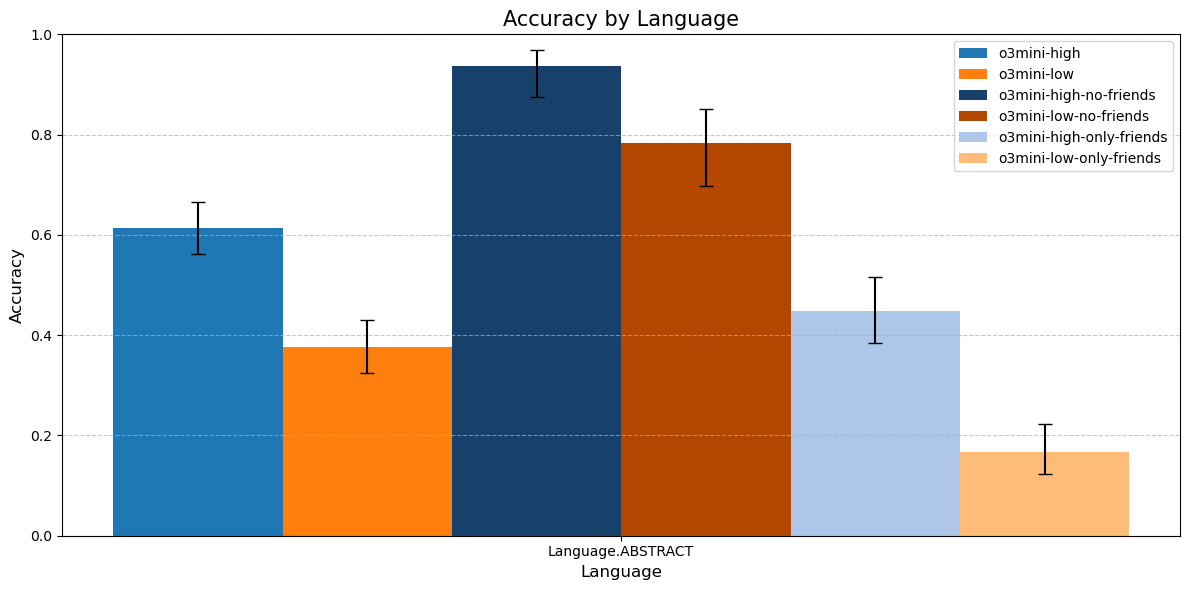


=========== Analysis by Complexity ===========
Accuracy by Complexity:


,Model,Complexity,Total,Correct,Accuracy,CI_Lower,CI_Upper
0,o3mini-high,3.0,98.0,69.0,0.704082,0.607397,0.785370
1,o3mini-high,4.0,85.0,52.0,0.611765,0.505475,0.708389
2,o3mini-high,5.0,76.0,42.0,0.552632,0.441003,0.659195
3,o3mini-high,6.0,68.0,38.0,0.558824,0.440817,0.670540
4,o3mini-high-no-friends,3.0,52.0,48.0,0.923077,0.818262,0.969681
5,o3mini-high-no-friends,4.0,33.0,31.0,0.939394,0.803934,0.983219
6,o3mini-high-no-friends,5.0,12.0,12.0,1.000000,0.757499,1.000000
7,o3mini-high-no-friends,6.0,14.0,13.0,0.928571,0.685307,0.987278
8,o3mini-high-only-friends,3.0,46.0,21.0,0.456522,0.321545,0.598201
9,o3mini-high-only-friends,4.0,52.0,21.0,0.403846,0.281595,0.539327


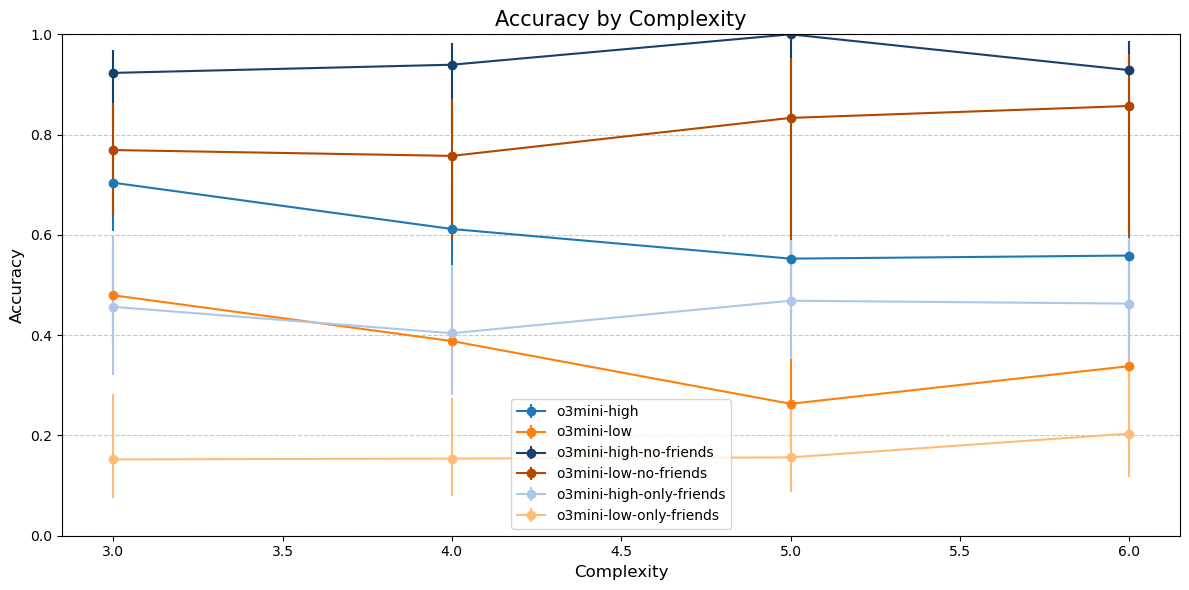


=========== Analysis by Branching ===========
Accuracy by Branching:


,Model,Branching,Total,Correct,Accuracy,CI_Lower,CI_Upper
0,o3mini-high,L,204.0,117.0,0.573529,0.504919,0.639422
1,o3mini-high,R,123.0,84.0,0.682927,0.596215,0.758559
2,o3mini-high-no-friends,L,62.0,58.0,0.935484,0.845523,0.974628
3,o3mini-high-no-friends,R,49.0,46.0,0.938776,0.834793,0.978960
4,o3mini-high-only-friends,L,142.0,59.0,0.415493,0.337706,0.497732
5,o3mini-high-only-friends,R,74.0,38.0,0.513514,0.401809,0.623884
6,o3mini-low,L,204.0,75.0,0.367647,0.304496,0.435691
7,o3mini-low,R,123.0,48.0,0.390244,0.308610,0.478526
8,o3mini-low-no-friends,L,62.0,54.0,0.870968,0.765504,0.933142
9,o3mini-low-no-friends,R,49.0,33.0,0.673469,0.533789,0.787927


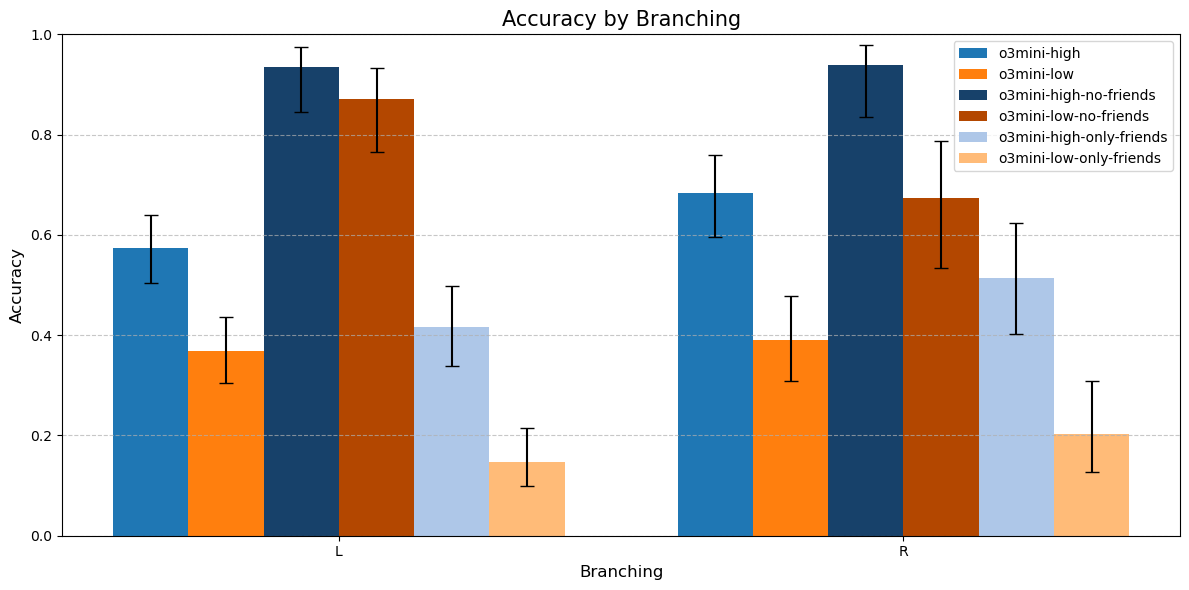


=========== Analysis by Complexity and Branching ===========
Accuracy by Complexity:


,Model,Complexity,Total,Correct,Accuracy,CI_Lower,CI_Upper
0,o3mini-high,3.0,98.0,69.0,0.704082,0.607397,0.785370
1,o3mini-high,4.0,85.0,52.0,0.611765,0.505475,0.708389
2,o3mini-high,5.0,76.0,42.0,0.552632,0.441003,0.659195
3,o3mini-high,6.0,68.0,38.0,0.558824,0.440817,0.670540
4,o3mini-high-no-friends,3.0,52.0,48.0,0.923077,0.818262,0.969681
5,o3mini-high-no-friends,4.0,33.0,31.0,0.939394,0.803934,0.983219
6,o3mini-high-no-friends,5.0,12.0,12.0,1.000000,0.757499,1.000000
7,o3mini-high-no-friends,6.0,14.0,13.0,0.928571,0.685307,0.987278
8,o3mini-high-only-friends,3.0,46.0,21.0,0.456522,0.321545,0.598201
9,o3mini-high-only-friends,4.0,52.0,21.0,0.403846,0.281595,0.539327


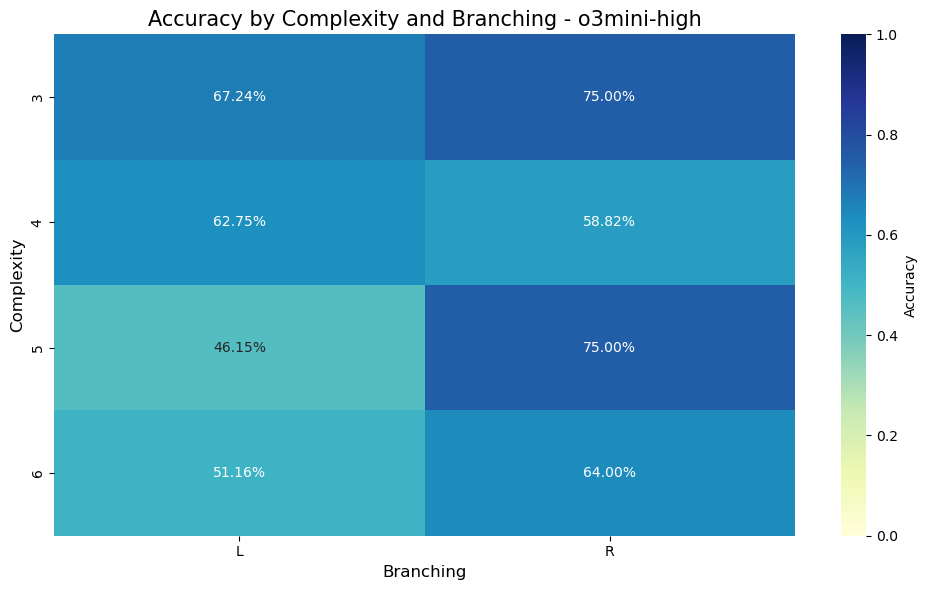

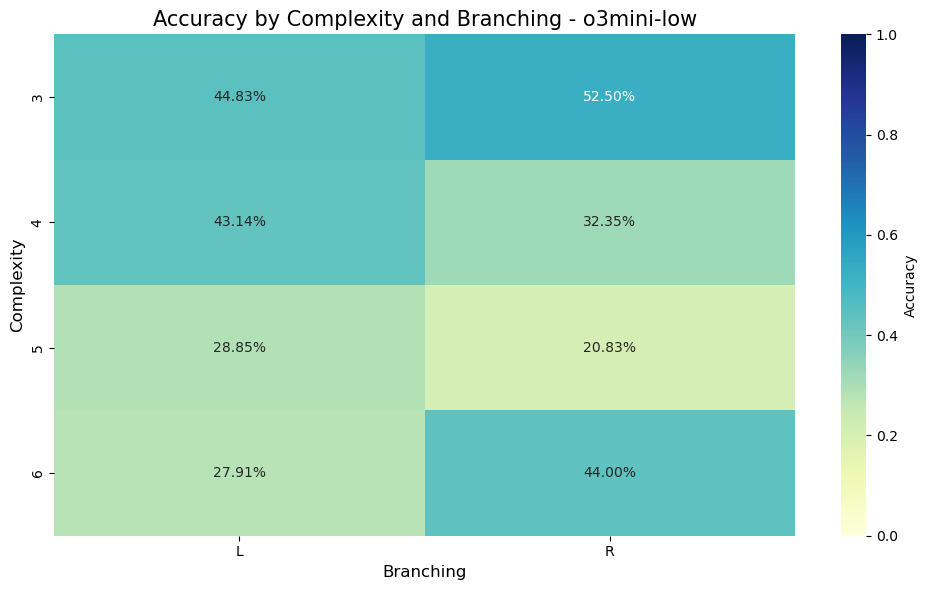

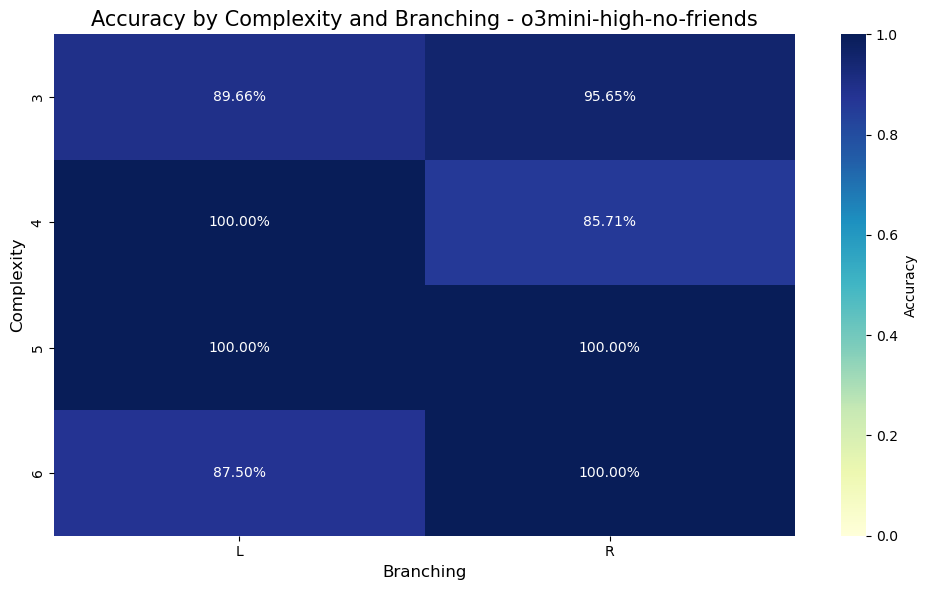

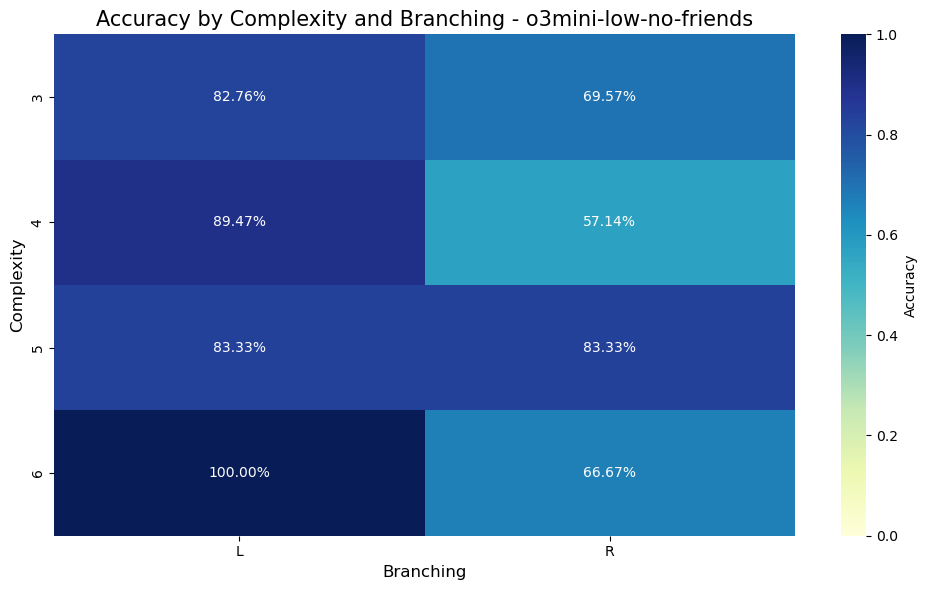

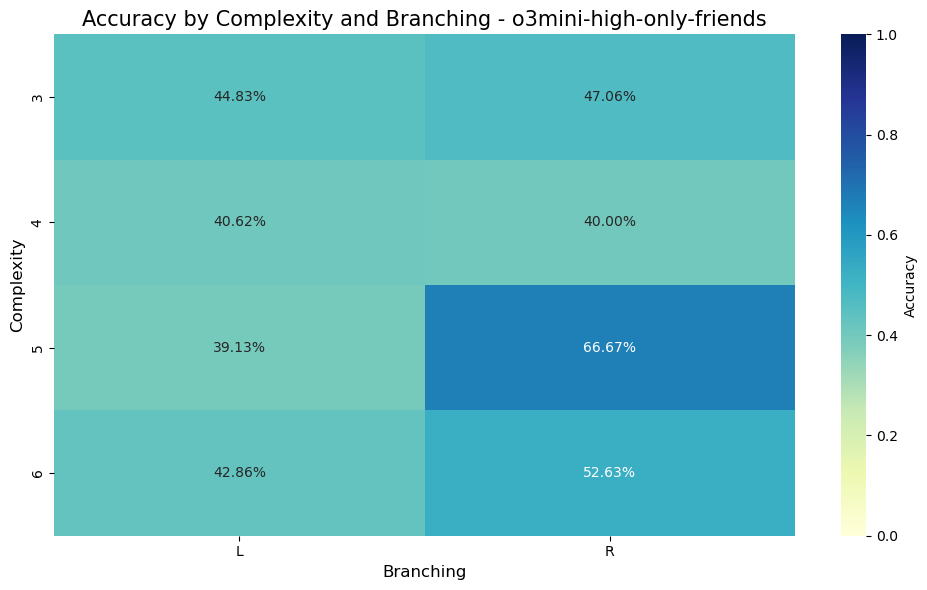

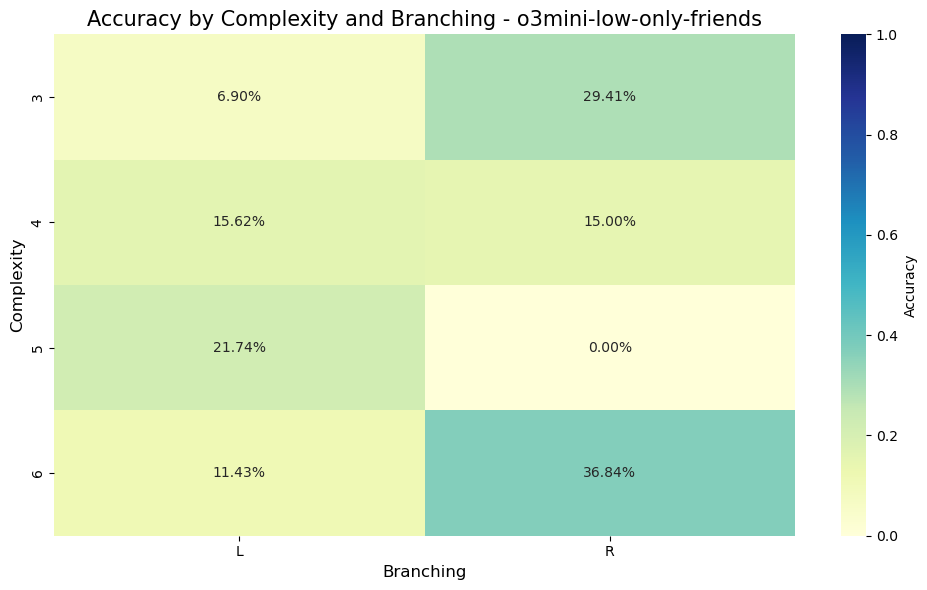


=========== Analysis by Aproach and Representation ===========
Accuracy by Representation:


,Model,Representation,Total,Correct,Accuracy,CI_Lower,CI_Upper
0,o3mini-high,Representation.ABSTRACT,327.0,201.0,0.614679,0.560888,0.665806
1,o3mini-high-no-friends,Representation.ABSTRACT,111.0,104.0,0.936937,0.875522,0.969120
2,o3mini-high-only-friends,Representation.ABSTRACT,216.0,97.0,0.449074,0.384206,0.515722
3,o3mini-low,Representation.ABSTRACT,327.0,123.0,0.376147,0.325366,0.429804
4,o3mini-low-no-friends,Representation.ABSTRACT,111.0,87.0,0.783784,0.698403,0.850179
5,o3mini-low-only-friends,Representation.ABSTRACT,216.0,36.0,0.166667,0.122884,0.222099


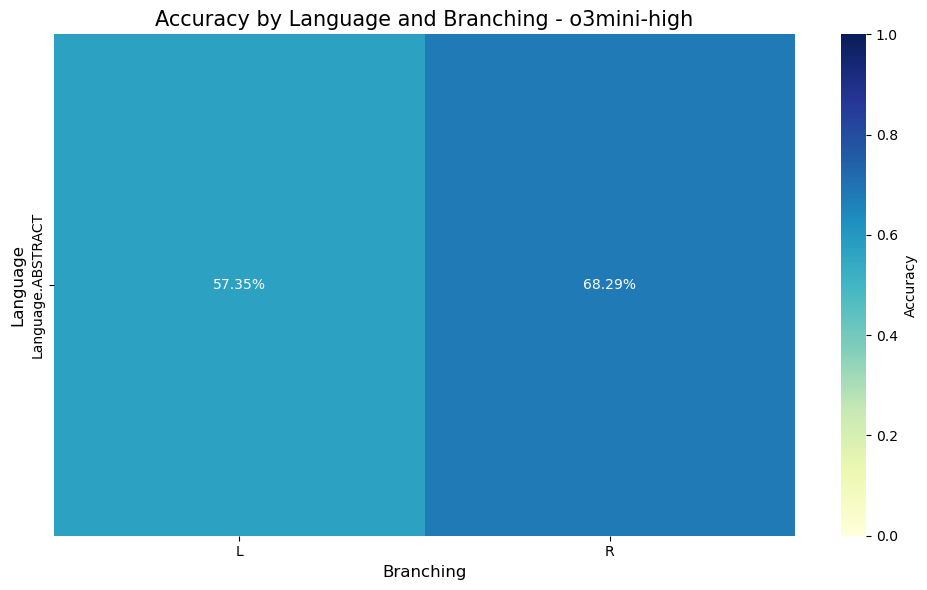

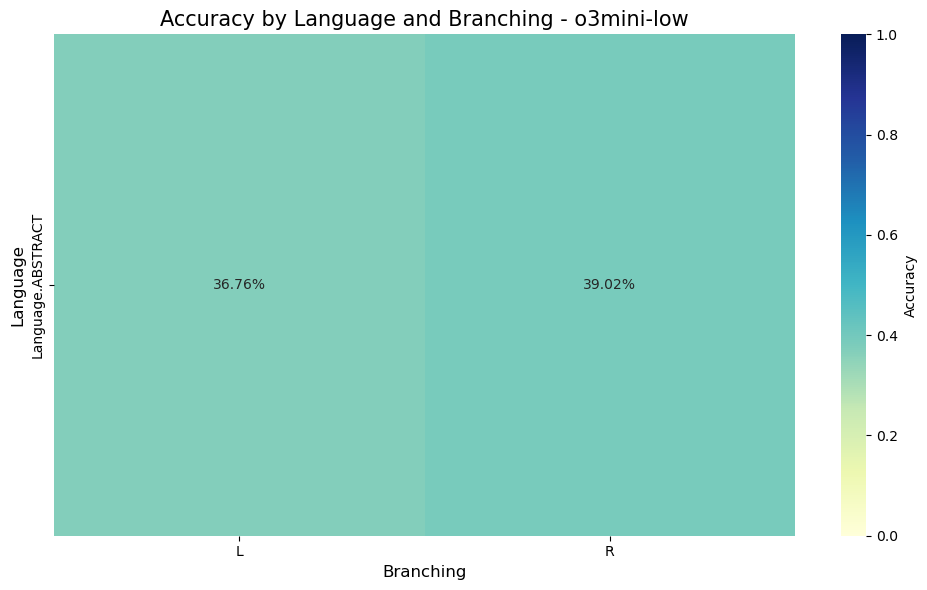

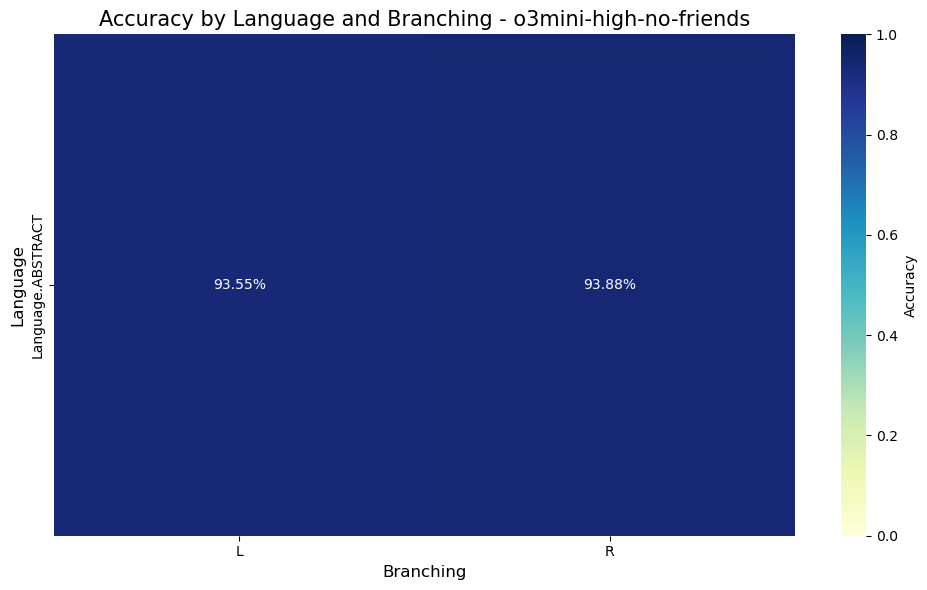

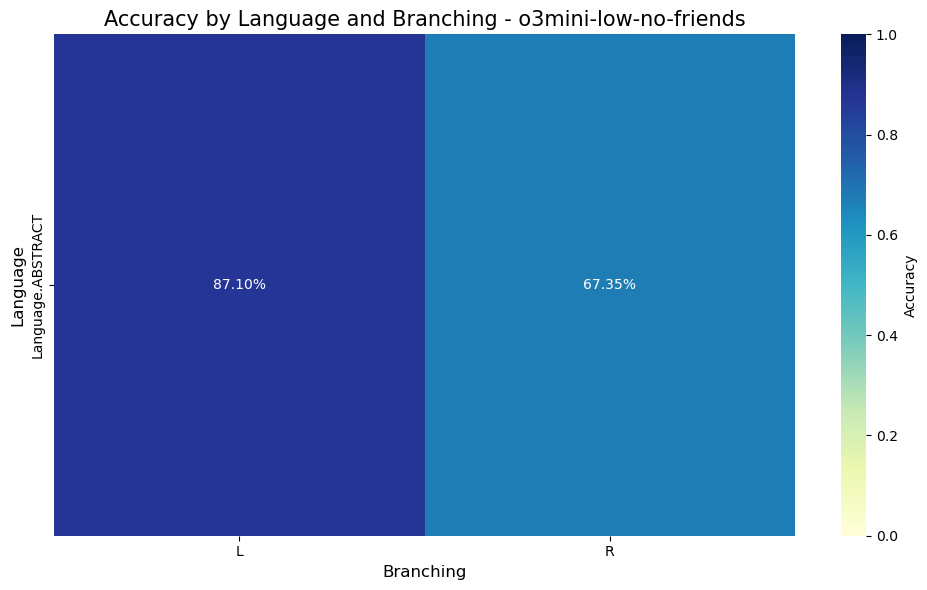

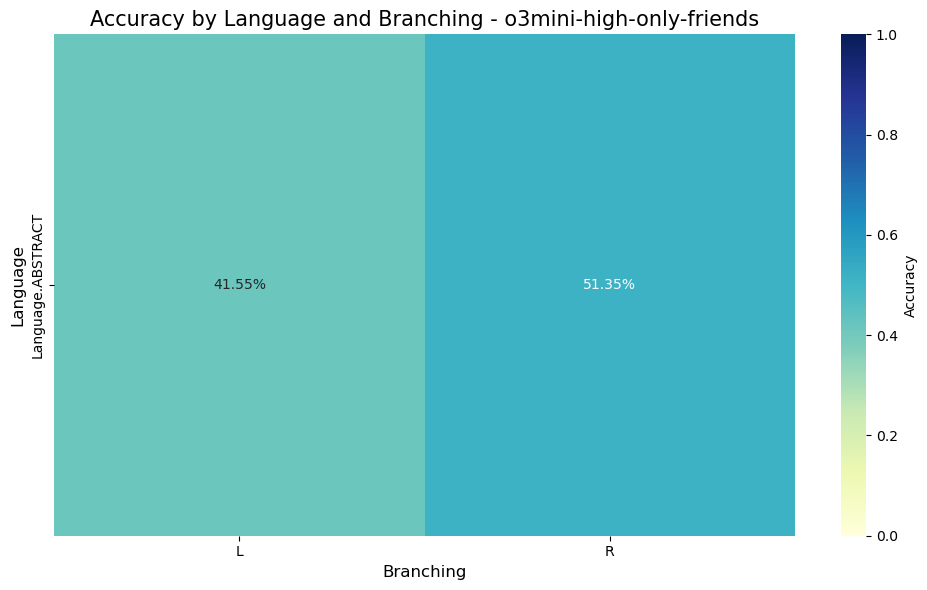

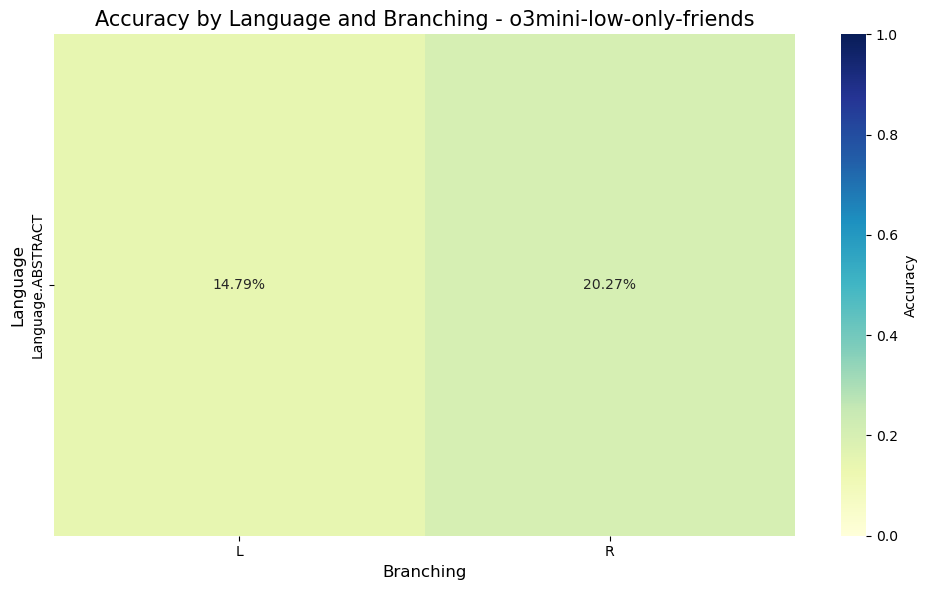


=========== Analysis by Aproach and Representation ===========
Accuracy by Representation:


,Model,Representation,Total,Correct,Accuracy,CI_Lower,CI_Upper
0,o3mini-high,Representation.ABSTRACT,327.0,201.0,0.614679,0.560888,0.665806
1,o3mini-high-no-friends,Representation.ABSTRACT,111.0,104.0,0.936937,0.875522,0.969120
2,o3mini-high-only-friends,Representation.ABSTRACT,216.0,97.0,0.449074,0.384206,0.515722
3,o3mini-low,Representation.ABSTRACT,327.0,123.0,0.376147,0.325366,0.429804
4,o3mini-low-no-friends,Representation.ABSTRACT,111.0,87.0,0.783784,0.698403,0.850179
5,o3mini-low-only-friends,Representation.ABSTRACT,216.0,36.0,0.166667,0.122884,0.222099


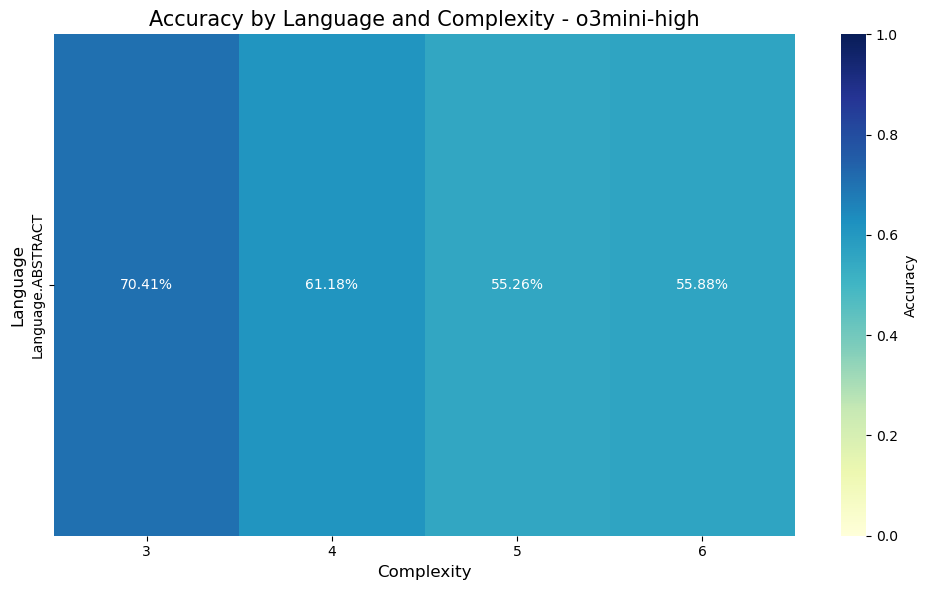

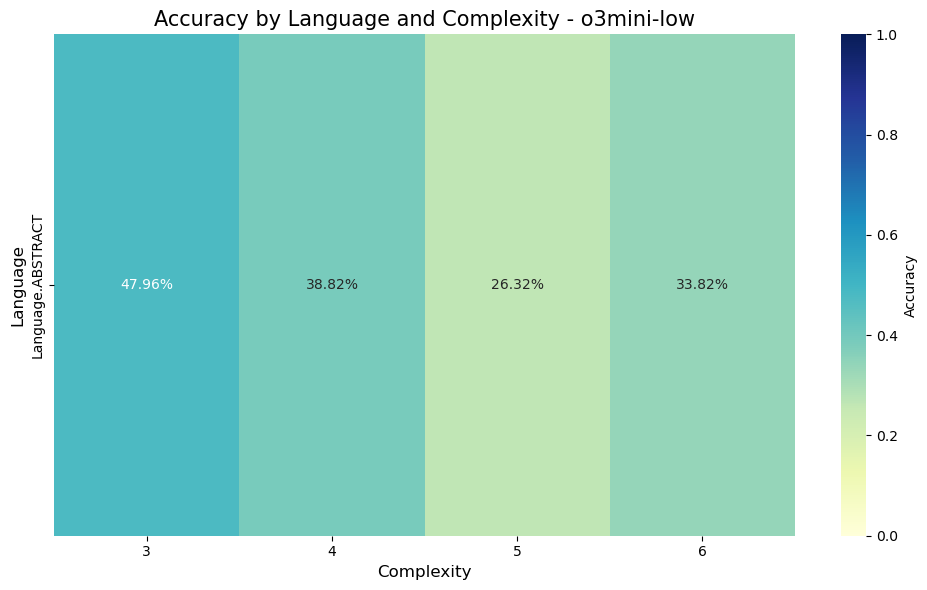

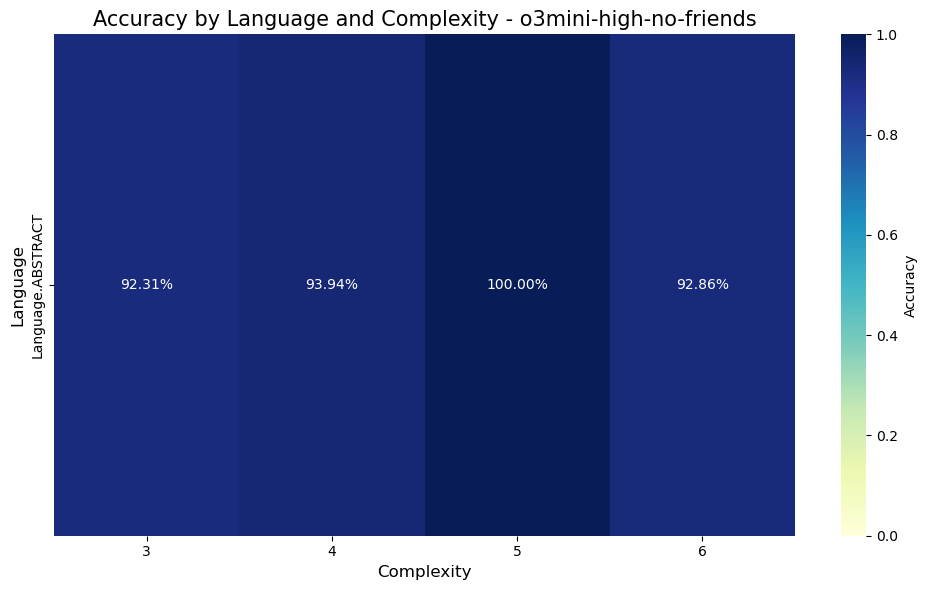

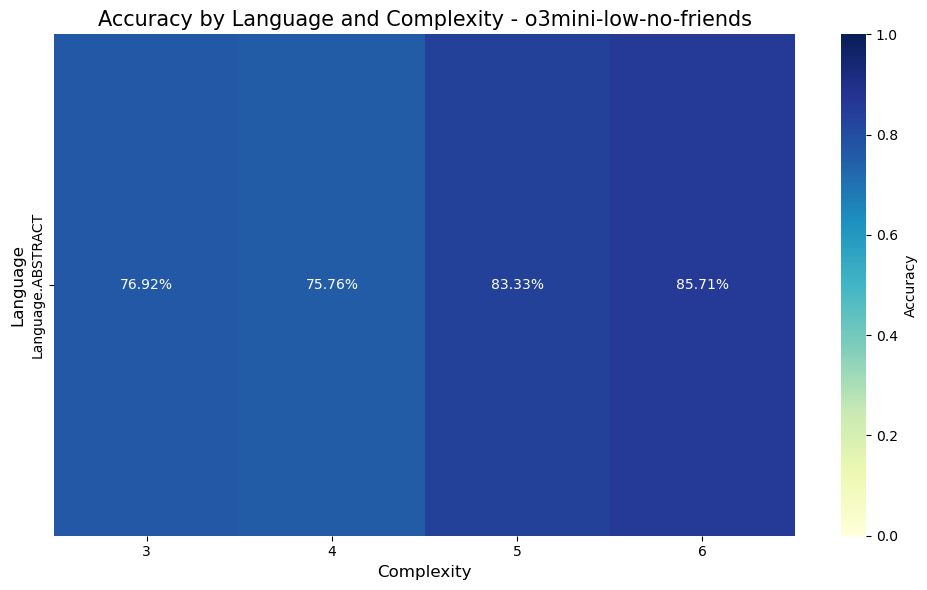

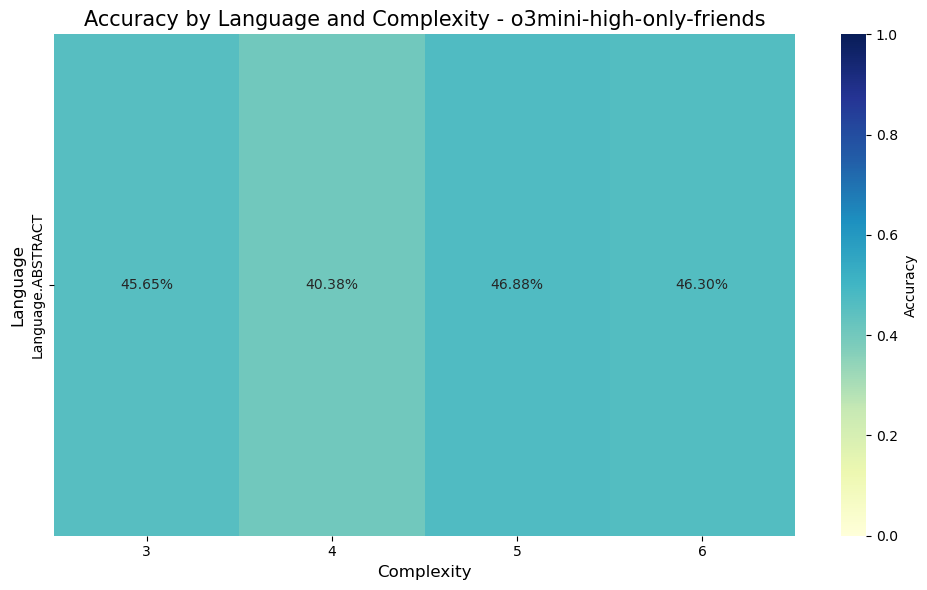

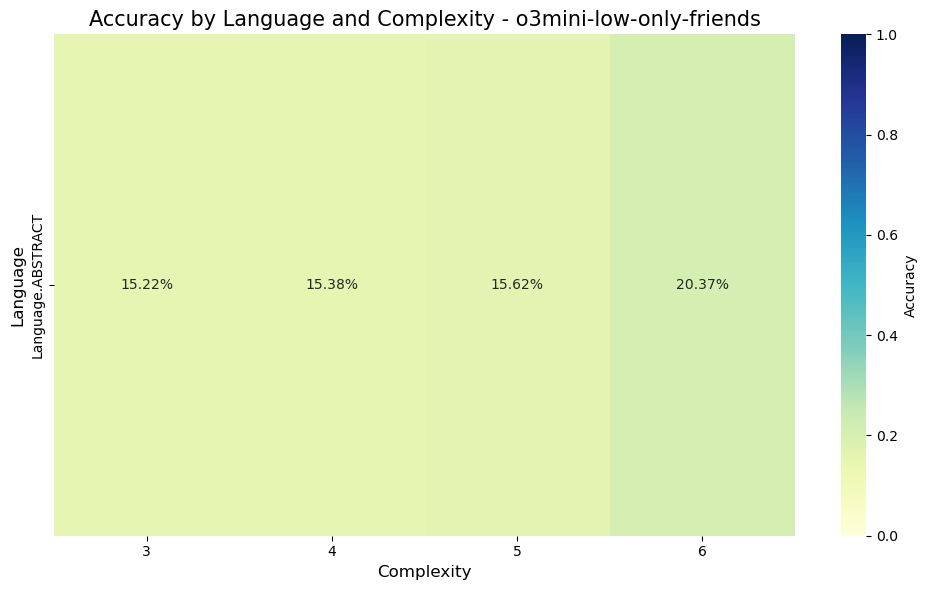


=========== Analysis by Aproach and Representation ===========
Accuracy by Approach:


,Model,Approach,Total,Correct,Accuracy,CI_Lower,CI_Upper
0,o3mini-high,SemanticApproach.EXTENSIONAL,327.0,201.0,0.614679,0.560888,0.665806
1,o3mini-high-no-friends,SemanticApproach.EXTENSIONAL,111.0,104.0,0.936937,0.875522,0.969120
2,o3mini-high-only-friends,SemanticApproach.EXTENSIONAL,216.0,97.0,0.449074,0.384206,0.515722
3,o3mini-low,SemanticApproach.EXTENSIONAL,327.0,123.0,0.376147,0.325366,0.429804
4,o3mini-low-no-friends,SemanticApproach.EXTENSIONAL,111.0,87.0,0.783784,0.698403,0.850179
5,o3mini-low-only-friends,SemanticApproach.EXTENSIONAL,216.0,36.0,0.166667,0.122884,0.222099


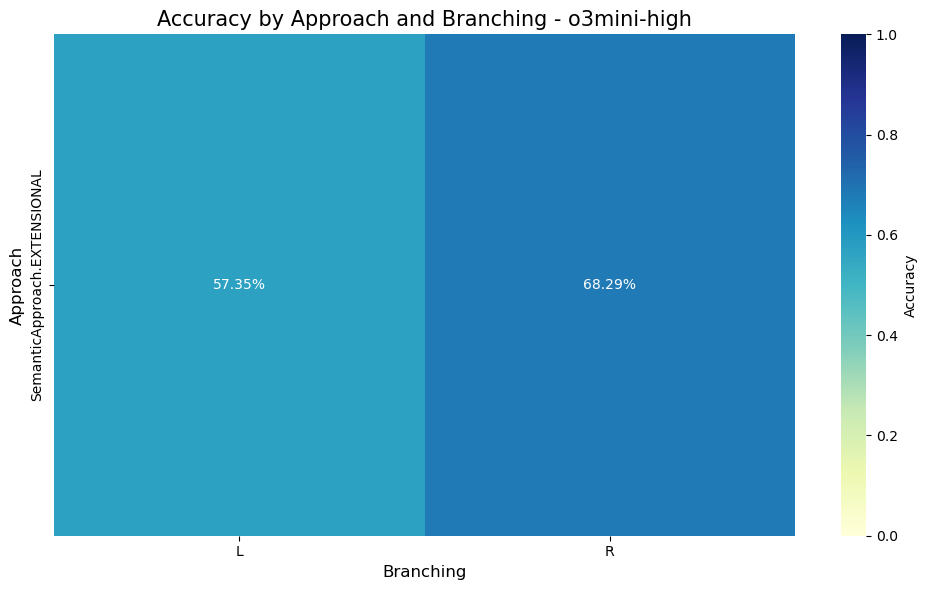

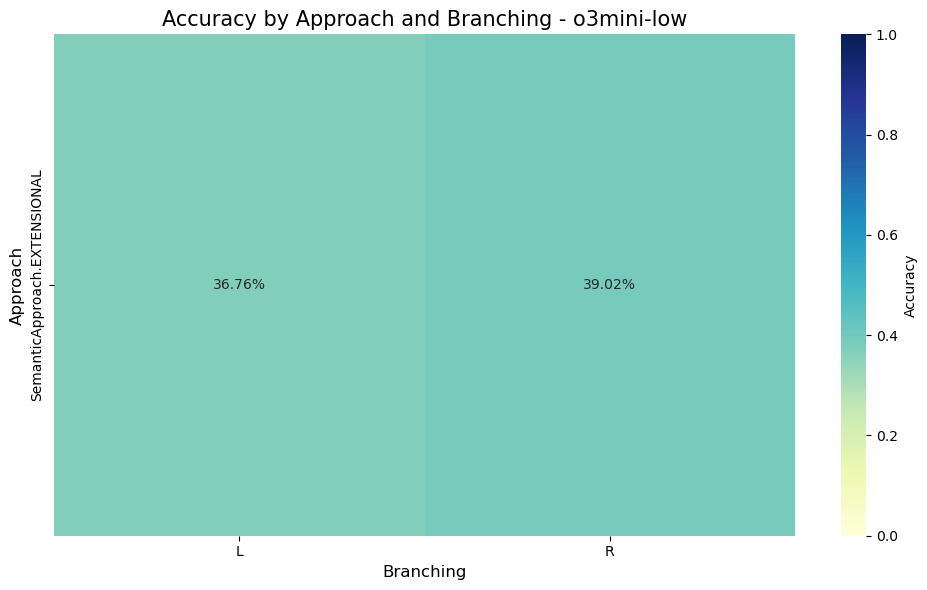

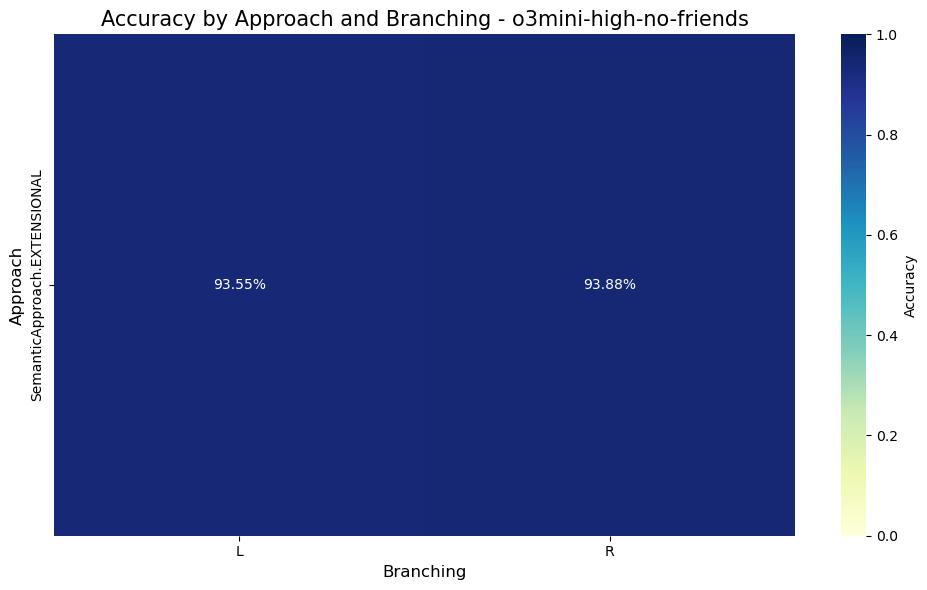

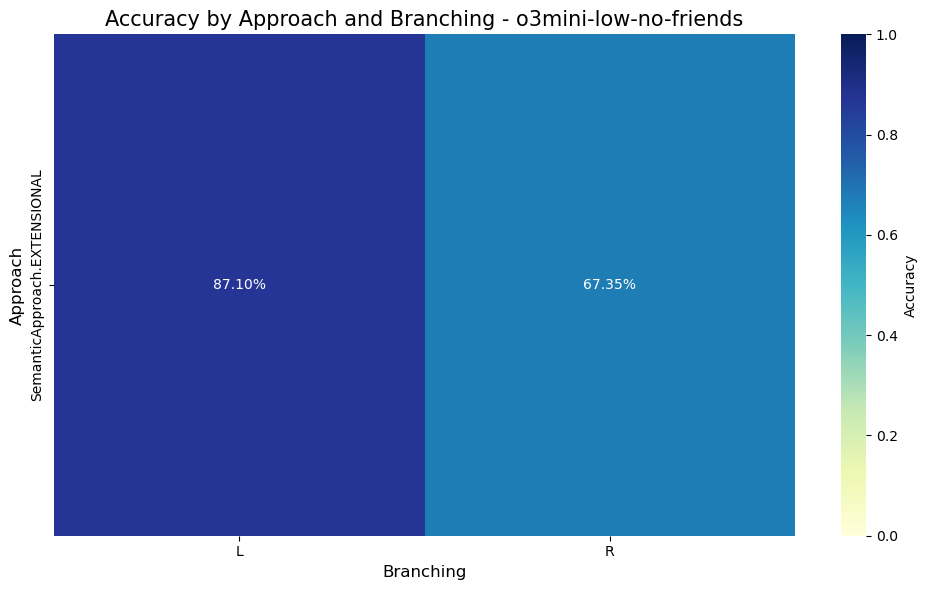

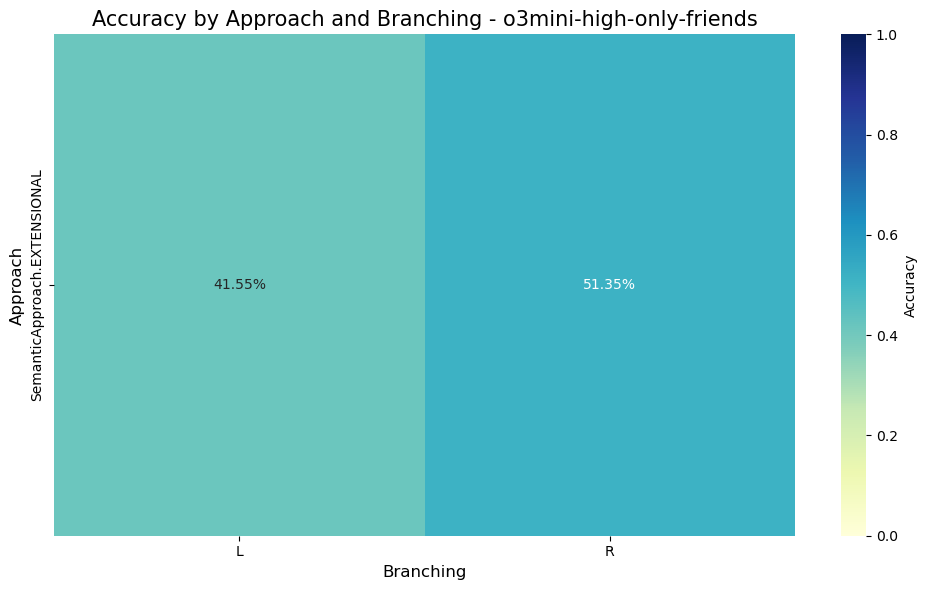

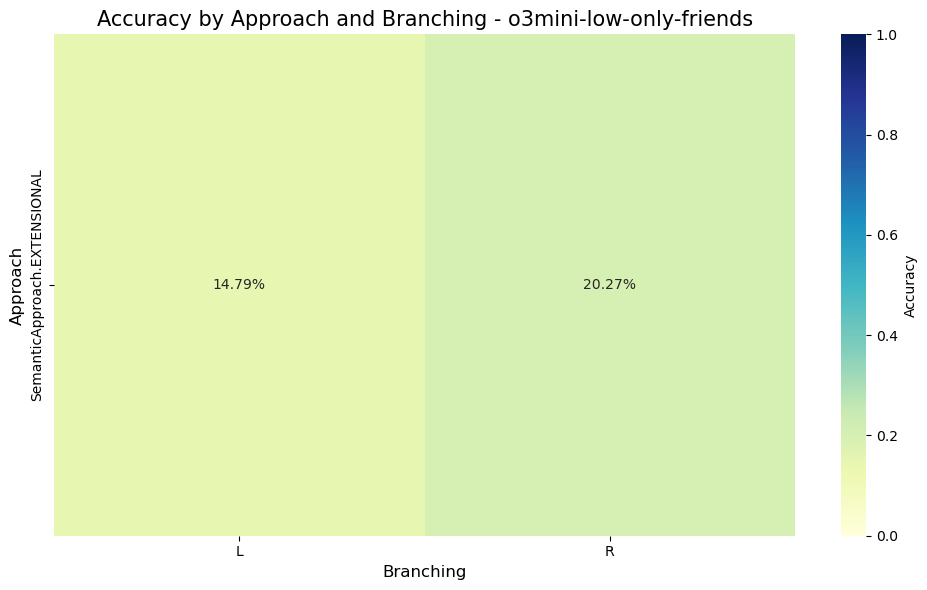


=========== Analysis by Aproach and Representation ===========
Accuracy by Approach:


,Model,Approach,Total,Correct,Accuracy,CI_Lower,CI_Upper
0,o3mini-high,SemanticApproach.EXTENSIONAL,327.0,201.0,0.614679,0.560888,0.665806
1,o3mini-high-no-friends,SemanticApproach.EXTENSIONAL,111.0,104.0,0.936937,0.875522,0.969120
2,o3mini-high-only-friends,SemanticApproach.EXTENSIONAL,216.0,97.0,0.449074,0.384206,0.515722
3,o3mini-low,SemanticApproach.EXTENSIONAL,327.0,123.0,0.376147,0.325366,0.429804
4,o3mini-low-no-friends,SemanticApproach.EXTENSIONAL,111.0,87.0,0.783784,0.698403,0.850179
5,o3mini-low-only-friends,SemanticApproach.EXTENSIONAL,216.0,36.0,0.166667,0.122884,0.222099


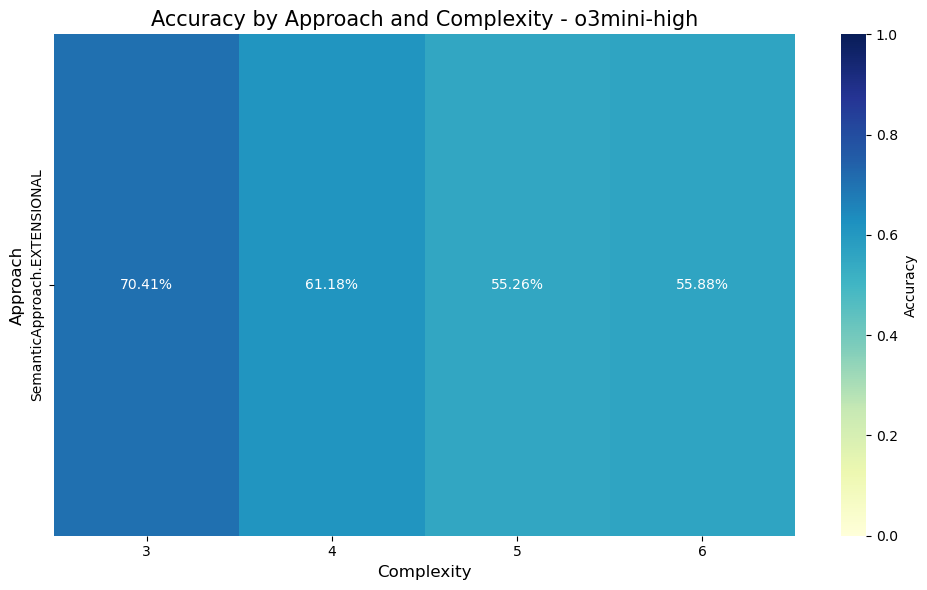

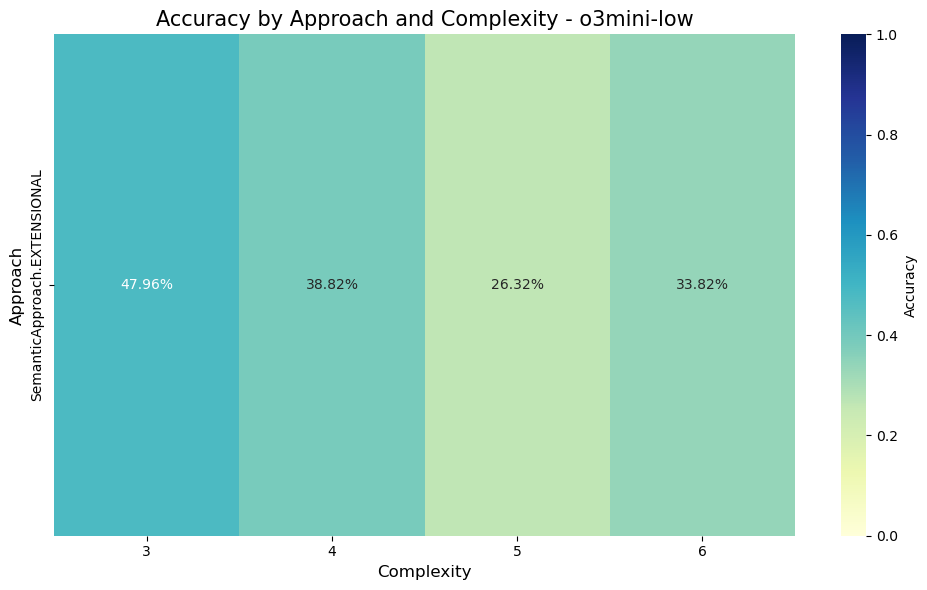

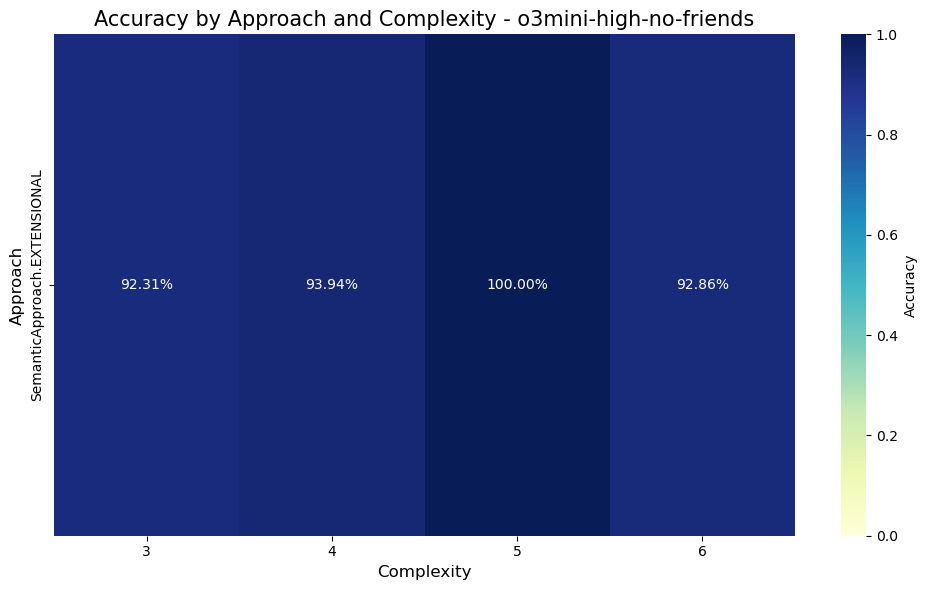

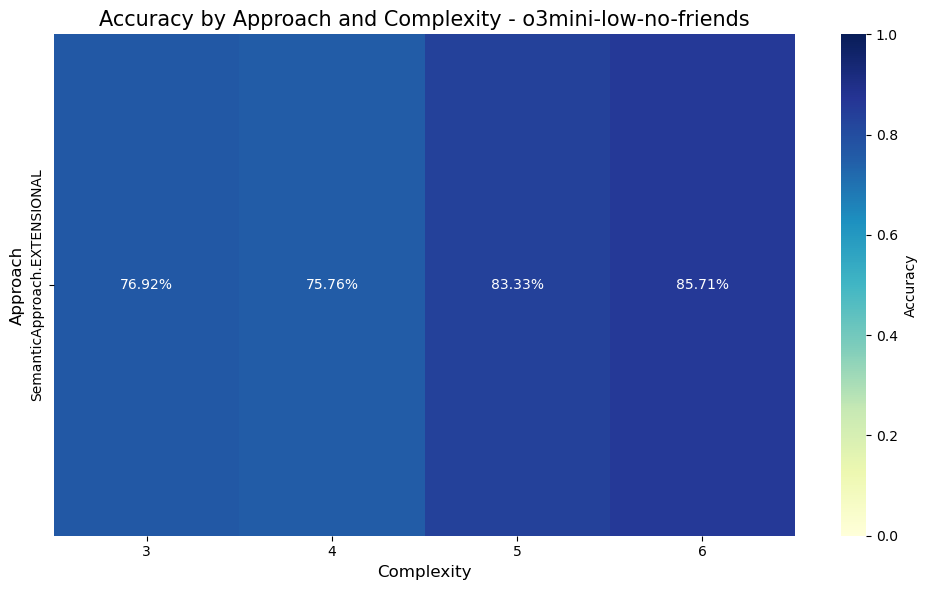

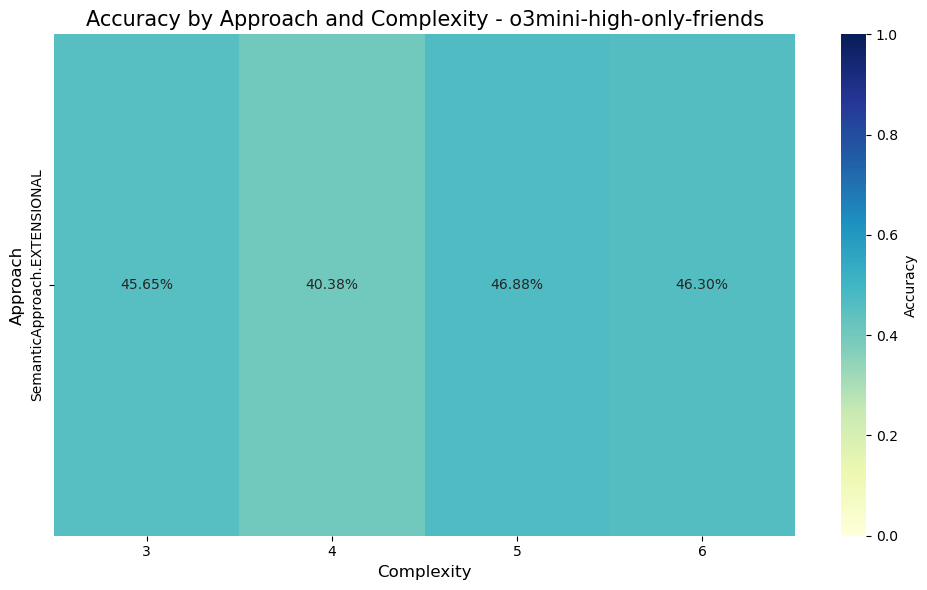

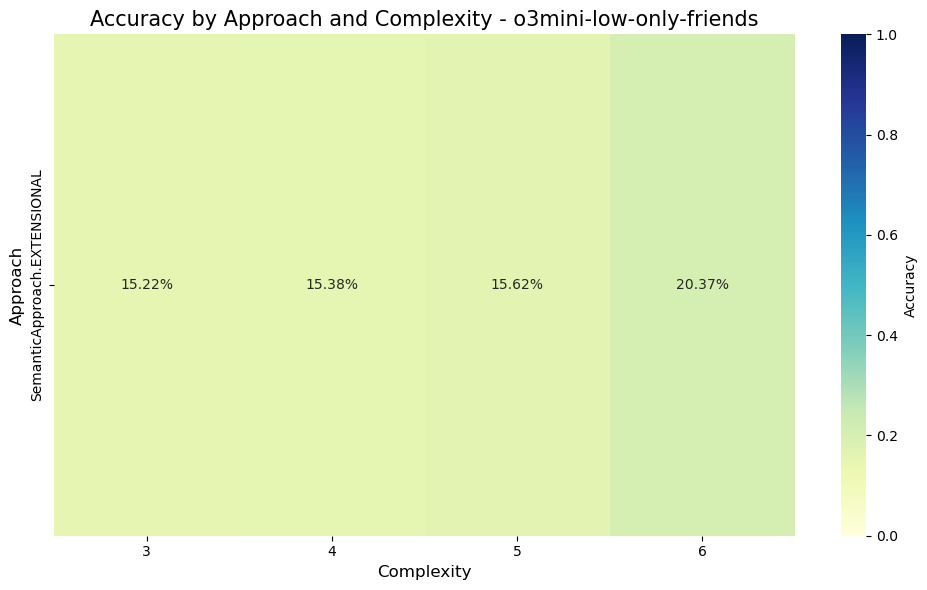

In [92]:
def insight_plots(df):
    # For representation and approach analyses
    print("=========== Analysis by Representation ===========")
    representation_df = analyze_and_visualize(df, 'Representation', plot_type='bar')


    # For complexity (using line plot)
    print("\n=========== Analysis by Complexity ===========")
    complexity_df = analyze_and_visualize(df, 'Complexity', plot_type='line')

    # For branching 
    print("\n=========== Analysis by Branching ===========")
    branching_df = analyze_and_visualize(df, 'Branching', plot_type='bar')

    # For complexity and branching combined (creates heatmap)
    print("\n=========== Analysis by Complexity and Branching ===========")
    analyze_and_visualize(df, 'Complexity', heatmap_col='Branching')

    print("\n=========== Analysis by Aproach and Representation ===========")
    analyze_and_visualize(df, 'Representation', heatmap_col='Branching')

    print("\n=========== Analysis by Aproach and Representation ===========")
    analyze_and_visualize(df, 'Representation', heatmap_col='Complexity')

    print("\n=========== Analysis by Aproach and Representation ===========")
    analyze_and_visualize(df, 'Approach', heatmap_col='Branching')

    print("\n=========== Analysis by Aproach and Representation ===========")
    analyze_and_visualize(df, 'Approach', heatmap_col='Complexity')



# assign each variant its own HEX color
COLOR_MAP = {
    'o3mini-high':            '#1f77b4',
    'o3mini-low':             '#ff7f0e',
    'o3mini-high-only-friends':'#aec7e8',
    'o3mini-low-only-friends':'#ffbb78',
    'o3mini-high-no-friends': '#17416a',
    'o3mini-low-no-friends':  '#b34700',
    # add any other variants if needed
}
sns.set_palette([COLOR_MAP[v] for v in COLOR_MAP])
# …existing code…
insight_plots(llms_results)


In [100]:
# Select a random row to display a full example
friendQuestions = o3mini_high_with_friends[o3mini_high_with_friends['Correct'] == True]
random_row = friendQuestions.sample(1).iloc[0]

print(f"Model: {random_row['Model_variant']}")
print(f"\nQuestion ID: {random_row['QuestionId']}")
print(f"Representation: {random_row['Representation']}")
print(f"Approach: {random_row['Approach']}")
print(f"Complexity: {random_row['Complexity']}")
print(f"Branching: {random_row['Branching']}")
print(f"Question: {random_row['Question']}")

print("\n=== PROMPT ===")
print(random_row['prompt'].replace(";;", "\n"))

print("\n=== MODEL ANSWER ===")
print(random_row['Model_Answer'])

print("\n=== CORRECT ANSWER ===")
print(f"{random_row['Answer']}")

print("\n=== EXTRACTED ANSWER ===")
print(f"{random_row['Extracted_Answer']}")

print(f"\nCorrect: {random_row['Correct']}")

Model: o3mini-high-only-friends

Question ID: 7_L_cpef4
Representation: Representation.ABSTRACT
Approach: SemanticApproach.EXTENSIONAL
Complexity: 5
Branching: L
Question: Chris's friend's enemy's parent's child

=== PROMPT ===
Imagine there are six people: Allison, Benjamin, Chris, Dean, Evan and Francisco. They have the following relationships to each other:

 Allison = y    Allison's enemy = h    Allison's friend = r    Benjamin's parent = b  Allison's child = t    
Benjamin = r   Benjamin's enemy = b   Benjamin's friend = y   Dean's parent = y      Chris's child = g      
Chris = h      Chris's enemy = y      Chris's friend = t      Evan's parent = h      Francisco's child = r  
Dean = t       Dean's enemy = g       Dean's friend = h       
Evan = g       Evan's enemy = t       Evan's friend = b       
Francisco = b  Francisco's enemy = r  Francisco's friend = g   
Here is how to figure out the answer to the following question:
Who is Evan's enemy's friend?

Here are the steps to a

In [88]:


# Calculate combined accuracy statistics
model_accuracies = {}
for model in llms_results['Model_variant'].unique():
    model_data = llms_results[llms_results['Model_variant'] == model]
    total = len(model_data)
    correct = model_data['Correct'].sum()
    accuracy = correct / total if total > 0 else 0
    if total > 0:
        z = 1.96  # 95% confidence
        p = accuracy
        denom = 1 + (z**2/total)
        center = (p + z**2/(2*total)) / denom
        err = z * np.sqrt(p*(1-p)/total + z**2/(4*total**2)) / denom
        ci_lower = max(0, center - err)
        ci_upper = min(1, center + err)
    else:
        ci_lower, ci_upper = 0, 0
    model_accuracies[model] = {
        'Total': total,
        'Correct': correct,
        'Accuracy': accuracy,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper
    }

# Calculate accuracy statistics for questions with friends (where 'f' is in QuestionId)
model_accuracies_friends = {}
for model in llms_filtered_friends['Model_variant'].unique():
    model_data = llms_filtered_friends[llms_filtered_friends['Model_variant'] == model]
    total = len(model_data)
    correct = model_data['Correct'].sum()
    accuracy = correct / total if total > 0 else 0
    if total > 0:
        z = 1.96
        p = accuracy
        denom = 1 + (z**2/total)
        center = (p + z**2/(2*total)) / denom
        err = z * np.sqrt(p*(1-p)/total + z**2/(4*total**2)) / denom
        ci_lower = max(0, center - err)
        ci_upper = min(1, center + err)
    else:
        ci_lower, ci_upper = 0, 0
    model_accuracies_friends[model] = {
        'Total': total,
        'Correct': correct,
        'Accuracy': accuracy,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper
    }

# Calculate accuracy statistics for questions with no friends (where 'f' is not in QuestionId)
model_accuracies_no_friends = {}
for model in llms_filtered_no_friends['Model_variant'].unique():
    model_data = llms_filtered_no_friends[llms_filtered_no_friends['Model_variant'] == model]
    total = len(model_data)
    correct = model_data['Correct'].sum()
    accuracy = correct / total if total > 0 else 0
    if total > 0:
        z = 1.96
        p = accuracy
        denom = 1 + (z**2/total)
        center = (p + z**2/(2*total)) / denom
        err = z * np.sqrt(p*(1-p)/total + z**2/(4*total**2)) / denom
        ci_lower = max(0, center - err)
        ci_upper = min(1, center + err)
    else:
        ci_lower, ci_upper = 0, 0
    model_accuracies_no_friends[model] = {
        'Total': total,
        'Correct': correct,
        'Accuracy': accuracy,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper
    }

# Create an enhanced comparison DataFrame with all three scenarios.
# We display only models that appear in all three dictionaries.
enhanced_comparison_df = pd.DataFrame({
    'Model': [],
    'Original Accuracy (Total)': [],
    'No-Friend Accuracy (Total)': [],
    'Friend-Only Accuracy (Total)': []
})

for model in model_accuracies:
    if (model in model_accuracies_no_friends) and (model in model_accuracies_friends):
        orig_acc = model_accuracies[model]['Accuracy']
        orig_total = model_accuracies[model]['Total']
        no_friend_acc = model_accuracies_no_friends[model]['Accuracy']
        no_friend_total = model_accuracies_no_friends[model]['Total']
        friend_acc = model_accuracies_friends[model]['Accuracy']
        friend_total = model_accuracies_friends[model]['Total']
        
        enhanced_comparison_df = pd.concat([enhanced_comparison_df, pd.DataFrame({
            'Model': [model],
            'Original Accuracy (Total)': [f"{orig_acc:.2%} ({orig_total})"],
            'No-Friend Accuracy (Total)': [f"{no_friend_acc:.2%} ({no_friend_total})"],
            'Friend-Only Accuracy (Total)': [f"{friend_acc:.2%} ({friend_total})"]
        })], ignore_index=True)

# Display the enhanced comparison table
display(enhanced_comparison_df)

,Model,Original Accuracy (Total),No-Friend Accuracy (Total),Friend-Only Accuracy (Total)
0,o3mini-high,61.47% (327),93.69% (111),44.91% (216)
1,o3mini-low,37.61% (327),78.38% (111),16.67% (216)


=========== No Friends Relationships =============
Accuracy by Complexity:


,Model,Complexity,Total,Correct,Accuracy,CI_Lower,CI_Upper
0,o3mini-high,3.0,52.0,48.0,0.923077,0.818262,0.969681
1,o3mini-high,4.0,33.0,31.0,0.939394,0.803934,0.983219
2,o3mini-high,5.0,12.0,12.0,1.000000,0.757499,1.000000
3,o3mini-high,6.0,14.0,13.0,0.928571,0.685307,0.987278
4,o3mini-low,3.0,52.0,40.0,0.769231,0.638660,0.862759
5,o3mini-low,4.0,33.0,25.0,0.757576,0.589751,0.871684
6,o3mini-low,5.0,12.0,10.0,0.833333,0.551964,0.953036
7,o3mini-low,6.0,14.0,12.0,0.857143,0.600581,0.959907



Accuracy by Branching:


,Model,Branching,Total,Correct,Accuracy,CI_Lower,CI_Upper
0,o3mini-high,L,62.0,58.0,0.935484,0.845523,0.974628
1,o3mini-high,R,49.0,46.0,0.938776,0.834793,0.978960
2,o3mini-low,L,62.0,54.0,0.870968,0.765504,0.933142
3,o3mini-low,R,49.0,33.0,0.673469,0.533789,0.787927


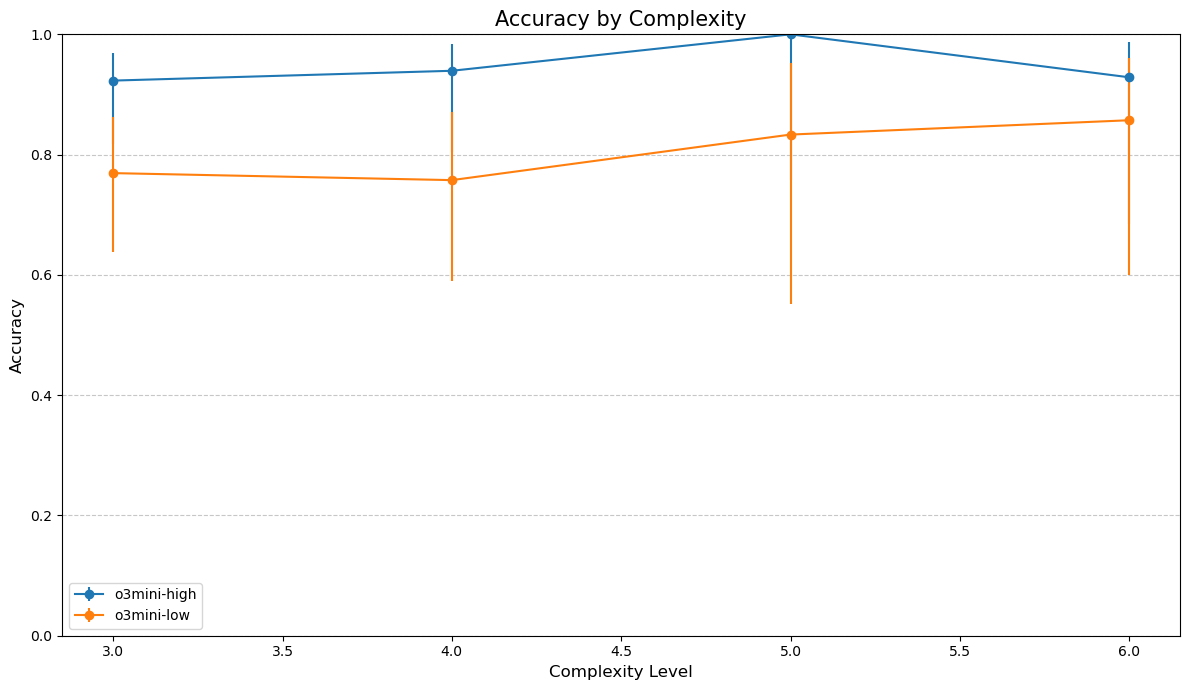

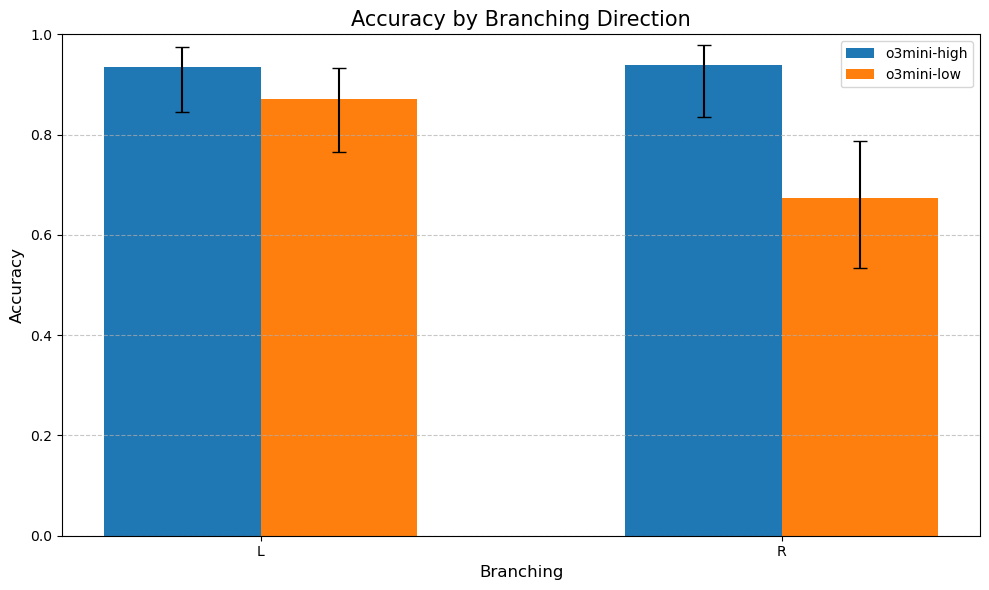

=========== No Friends Relationships - Balanced DataFrame =============
Minimum group count per combination: 12
Accuracy by Complexity:


C:\Users\Bart Evelo\AppData\Local\Temp\ipykernel_10144\2870246641.py:220: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(n=min_count, random_state=random_state))


,Model,Complexity,Total,Correct,Accuracy,CI_Lower,CI_Upper
0,o3mini-high,3.0,11.0,10.0,0.909091,0.622635,0.983768
1,o3mini-high,4.0,13.0,12.0,0.923077,0.666855,0.986290
2,o3mini-high,5.0,12.0,12.0,1.000000,0.757499,1.000000
3,o3mini-high,6.0,12.0,11.0,0.916667,0.646114,0.985135
4,o3mini-low,3.0,13.0,11.0,0.846154,0.577648,0.956743
5,o3mini-low,4.0,11.0,8.0,0.727273,0.434350,0.902541
6,o3mini-low,5.0,12.0,10.0,0.833333,0.551964,0.953036
7,o3mini-low,6.0,12.0,10.0,0.833333,0.551964,0.953036



Accuracy by Branching:


,Model,Branching,Total,Correct,Accuracy,CI_Lower,CI_Upper
0,o3mini-high,L,24.0,23.0,0.958333,0.797578,0.992607
1,o3mini-high,R,24.0,22.0,0.916667,0.741508,0.976842
2,o3mini-low,L,24.0,21.0,0.875000,0.689957,0.956557
3,o3mini-low,R,24.0,18.0,0.750000,0.551002,0.880008


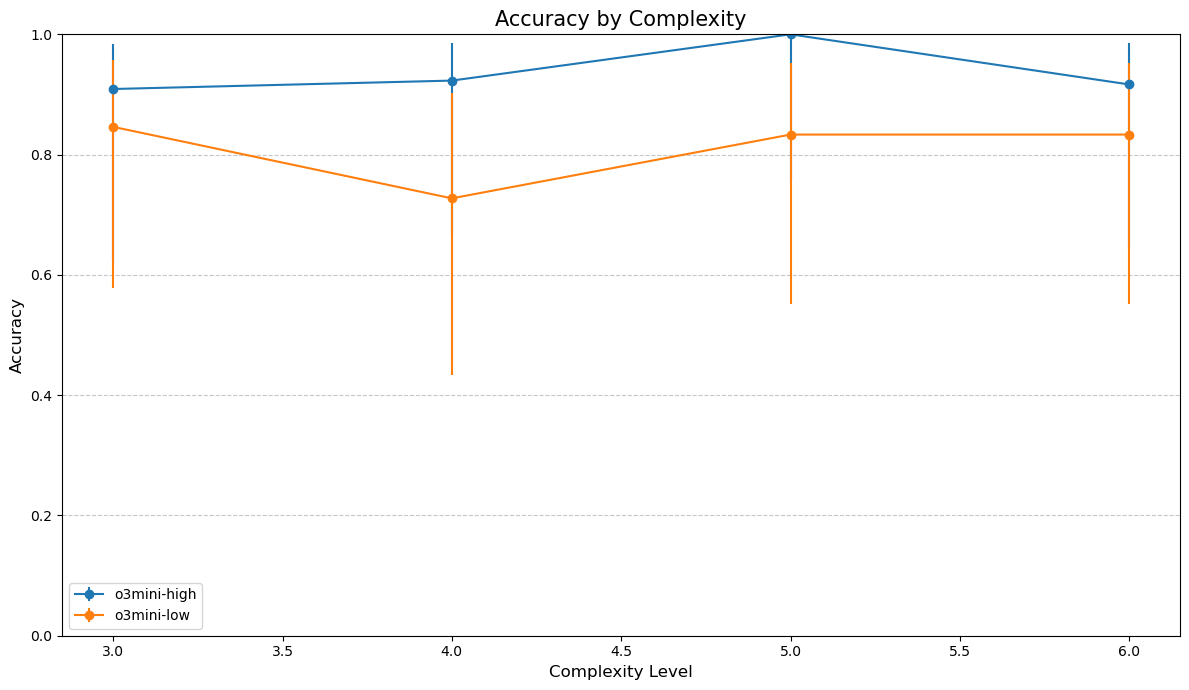

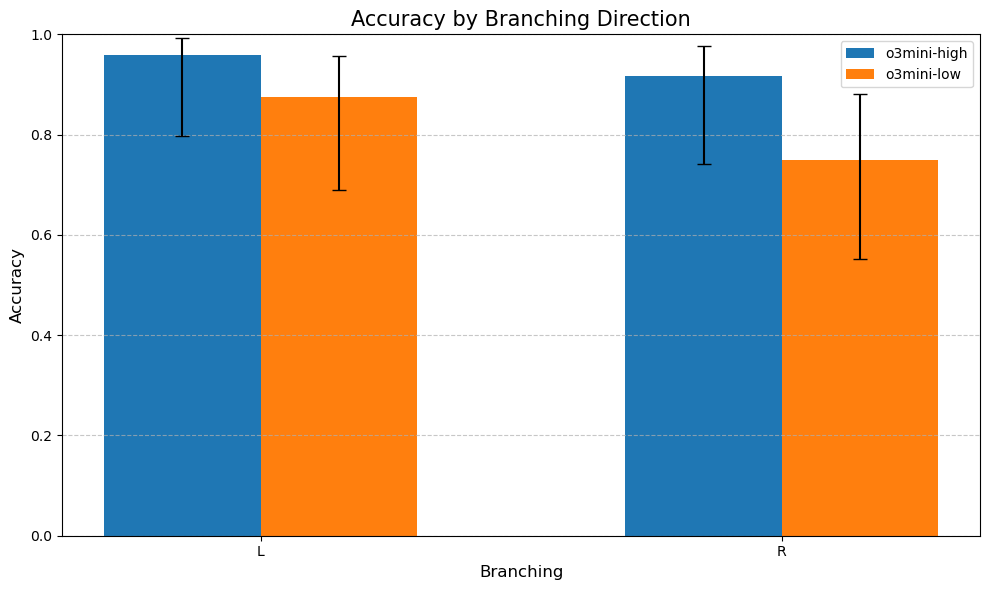

In [89]:
# Function to calculate accuracy statistics with a 95% confidence interval
def calculate_accuracy_with_ci(data):
    total = len(data)
    correct = data['Correct'].sum()
    accuracy = correct / total if total > 0 else 0

    # Calculate 95% confidence interval using the Wilson score interval
    if total > 0:
        z = 1.96  # 95% confidence
        p = accuracy
        denom = 1 + (z**2 / total)
        center = (p + z**2 / (2 * total)) / denom
        err = z * np.sqrt(p * (1 - p) / total + z**2 / (4 * total**2)) / denom
        ci_lower = max(0, center - err)
        ci_upper = min(1, center + err)
    else:
        ci_lower, ci_upper = 0, 0

    return {
        'Total': total,
        'Correct': correct,
        'Accuracy': accuracy,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper
    }

# Function to compute summary dictionaries and tables
def create_accuracy_tables(df):
    # Calculate accuracy by Complexity for each model
    complexity_results = {}
    for model in df['Model_variant'].unique():
        model_data = df[df['Model_variant'] == model]
        complexity_results[model] = {}
        for complexity in model_data['Complexity'].unique():
            subset = model_data[model_data['Complexity'] == complexity]
            complexity_results[model][complexity] = calculate_accuracy_with_ci(
                subset
            )

    # Calculate accuracy by Branching for each model
    branching_results = {}
    for model in df['Model_variant'].unique():
        model_data = df[df['Model_variant'] == model]
        branching_results[model] = {}
        for branching in model_data['Branching'].unique():
            subset = model_data[model_data['Branching'] == branching]
            branching_results[model][branching] = calculate_accuracy_with_ci(
                subset
            )

    # Create complexity results DataFrame
    complexity_df = pd.DataFrame({
        'Model': [],
        'Complexity': [],
        'Total': [],
        'Correct': [],
        'Accuracy': [],
        'CI_Lower': [],
        'CI_Upper': []
    })

    for model in complexity_results:
        for complexity in complexity_results[model]:
            stats = complexity_results[model][complexity]
            temp_df = pd.DataFrame({
                'Model': [model],
                'Complexity': [complexity],
                'Total': [stats['Total']],
                'Correct': [stats['Correct']],
                'Accuracy': [stats['Accuracy']],
                'CI_Lower': [stats['CI_Lower']],
                'CI_Upper': [stats['CI_Upper']]
            })
            complexity_df = pd.concat([complexity_df, temp_df], ignore_index=True)

    # Create branching results DataFrame
    branching_df = pd.DataFrame({
        'Model': [],
        'Branching': [],
        'Total': [],
        'Correct': [],
        'Accuracy': [],
        'CI_Lower': [],
        'CI_Upper': []
    })

    for model in branching_results:
        for branching in branching_results[model]:
            stats = branching_results[model][branching]
            temp_df = pd.DataFrame({
                'Model': [model],
                'Branching': [branching],
                'Total': [stats['Total']],
                'Correct': [stats['Correct']],
                'Accuracy': [stats['Accuracy']],
                'CI_Lower': [stats['CI_Lower']],
                'CI_Upper': [stats['CI_Upper']]
            })
            branching_df = pd.concat([branching_df, temp_df], ignore_index=True)

    return complexity_df, branching_df, complexity_results, branching_results

# Function to generate the accuracy-by-complexity plot
def plot_accuracy_by_complexity(complexity_results):
    plt.figure(figsize=(12, 7))
    for model in complexity_results:
        complexities = []
        accuracies = []
        ci_lowers = []
        ci_uppers = []
        for complexity in sorted(complexity_results[model].keys()):
            stats = complexity_results[model][complexity]
            complexities.append(complexity)
            accuracies.append(stats['Accuracy'])
            ci_lowers.append(stats['Accuracy'] - stats['CI_Lower'])
            ci_uppers.append(stats['CI_Upper'] - stats['Accuracy'])
        plt.errorbar(
            complexities,
            accuracies,
            yerr=[ci_lowers, ci_uppers],
            marker='o',
            linestyle='-',
            label=model
        )
    plt.title('Accuracy by Complexity', fontsize=15)
    plt.xlabel('Complexity Level', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.ylim(0, 1.0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Function to generate the accuracy-by-branching plot
def plot_accuracy_by_branching(branching_results):
    # Get a sorted list of all branching categories encountered
    branching_categories = sorted({
        branch
        for model in branching_results
        for branch in branching_results[model].keys()
    })
    x_positions = np.arange(len(branching_categories))
    models = list(branching_results.keys())
    width = 0.3

    plt.figure(figsize=(10, 6))
    for i, model in enumerate(models):
        stats_for_model = []
        errors_lower = []
        errors_upper = []
        # Ensure all branching categories appear; if not available for a model,
        # assign NaN.
        for branch in branching_categories:
            if branch in branching_results[model]:
                stats = branching_results[model][branch]
                stats_for_model.append(stats['Accuracy'])
                errors_lower.append(stats['Accuracy'] - stats['CI_Lower'])
                errors_upper.append(stats['CI_Upper'] - stats['Accuracy'])
            else:
                stats_for_model.append(np.nan)
                errors_lower.append(np.nan)
                errors_upper.append(np.nan)

        pos = x_positions - width + (i * width)
        plt.bar(pos, stats_for_model, width=width, label=model)
        plt.errorbar(
            pos,
            stats_for_model,
            yerr=[errors_lower, errors_upper],
            fmt='none',
            ecolor='black',
            capsize=5
        )

    plt.title('Accuracy by Branching Direction', fontsize=15)
    plt.xlabel('Branching', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.xticks(x_positions - width / len(models), branching_categories)
    plt.ylim(0, 1.0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Wrapper function that takes a DataFrame and outputs the tables and plots.
def generate_accuracy_summary(df):
    (complexity_df,
     branching_df,
     complexity_results,
     branching_results) = create_accuracy_tables(df)
    
    print("Accuracy by Complexity:")
    # In Jupyter you can use display(complexity_df.sort_values(...))
    # Here we simply print the sorted dataframe:
    display(complexity_df.sort_values(['Model', 'Complexity']).reset_index(
        drop=True
    ))
    
    print("\nAccuracy by Branching:")
    display(branching_df.sort_values(['Model', 'Branching']).reset_index(
        drop=True
    ))
    
    # Plot the charts
    plot_accuracy_by_complexity(complexity_results)
    plot_accuracy_by_branching(branching_results)
    
    return complexity_df, branching_df


def balance_dataframe_by_columns(df, columns, random_state=42):
    # Calculate the number of rows in each group.
    group_sizes = df.groupby(columns).size()
    min_count = group_sizes.min()
    print("Minimum group count per combination:", min_count)
    
    # For each group, sample min_count rows.
    balanced_df = (
        df.groupby(columns, group_keys=False)
          .apply(lambda group: group.sample(n=min_count, random_state=random_state))
          .reset_index(drop=True)
    )
    
    return balanced_df


print("=========== No Friends Relationships =============")
complexity_df, branching_df = generate_accuracy_summary(llms_filtered_no_friends)
print("=========== No Friends Relationships - Balanced DataFrame =============")
lms_no_friends_balanced = balance_dataframe_by_columns(llms_filtered_no_friends, ['Branching', 'Complexity'])
complexity_df, branching_df = generate_accuracy_summary(lms_no_friends_balanced)